In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import time
import pickle
import warnings

In [2]:
os.makedirs(r'預測結果圖\Plant2第二號發電機組', exist_ok=True)

In [3]:
# 讓圖表能顯示中文字體
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']  # 微軟正黑體
plt.rcParams['axes.unicode_minus'] = False  # 正確顯示負號

<h3 style='color:blue'> definition 函式庫 </h3>

In [4]:
def classify_day_night(dt):
    '''
    根據時間區間判斷白天或晚上
    白天：05:45 ~ 18:45
    晚上：19:00 ~ 次日 05:30
    '''
    t = dt.time()
    if time(5, 45) <= t <= time(18, 45):
        return 'Daytime' # 白天
    else:
        return 'Night' # 晚上

In [5]:
def encode_time_features(df):
    """
    將 datetime index 分解為時間欄位，並加入週期性時間變數（sin, cos）。
    傳回處理後的 DataFrame，包含指定欄位順序。
    """
    # 時間欄位分解
    df['HOUR'] = df.index.hour # 小時
    df['MINUTE'] = df.index.minute # 分鐘
    df['MINUTES_PASS'] = df['HOUR'] * 60 + df['MINUTE'] #  把一整天的時間轉換成「當天過了幾分鐘」的數值

    # 加入週期性時間變數（sin/cos）
    # 因為時間具有「週期性」，加入"週期性時間編碼"。
    # 將時間轉換成週期性變數（sin/cos），讓模型可以理解「時間是循環的」，而不是線性的。
    # 這樣模型就可以理解「00:00 跟 23:45 很接近」，而不會誤以為差很遠。
    df['TIME_SIN'] = np.sin(2 * np.pi * df['MINUTES_PASS'] / 1440)
    df['TIME_COS'] = np.cos(2 * np.pi * df['MINUTES_PASS'] / 1440)

    # 指定回傳欄位順序
    df = df[['HOUR', 'MINUTE', 'MINUTES_PASS', 'TIME_SIN', 'TIME_COS',
                       'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 
                       'DC_POWER' ]]# 指定欄位順序
    
    return df

<h2> 第二號發電機組發電量與天氣資訊 </h2>

In [6]:
gen_2 = pd.read_csv(r'Plant_2_Generation_Data.csv') # 發電資料
sens_2 = pd.read_csv(r'Plant_2_Weather_Sensor_Data.csv') # 氣象感測數據

In [7]:
# 避免原始資料被修改
df_gen2 = gen_2.copy()
df_sens2 = sens_2.copy()

In [8]:
# 調整資料格式
df_gen2['DATE_TIME'] = pd.to_datetime(df_gen2['DATE_TIME'],format = '%Y-%m-%d %H:%M:%S') # 留意此處格式為'%Y-%m-%d %H:%M:%S'
df_sens2['DATE_TIME'] = pd.to_datetime(df_sens2['DATE_TIME'],format = '%Y-%m-%d %H:%M:%S')

In [9]:
df_gen2 # 發電資料

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,4136001,4UPUqMRk7TRMgml,0.0,0.0,9425.000000,2.429011e+06
1,2020-05-15 00:00:00,4136001,81aHJ1q11NBPMrL,0.0,0.0,0.000000,1.215279e+09
2,2020-05-15 00:00:00,4136001,9kRcWv60rDACzjR,0.0,0.0,3075.333333,2.247720e+09
3,2020-05-15 00:00:00,4136001,Et9kgGMDl729KT4,0.0,0.0,269.933333,1.704250e+06
4,2020-05-15 00:00:00,4136001,IQ2d7wF4YD8zU1Q,0.0,0.0,3177.000000,1.994153e+07
...,...,...,...,...,...,...,...
67693,2020-06-17 23:45:00,4136001,q49J1IKaHRwDQnt,0.0,0.0,4157.000000,5.207580e+05
67694,2020-06-17 23:45:00,4136001,rrq4fwE8jgrTyWY,0.0,0.0,3931.000000,1.211314e+08
67695,2020-06-17 23:45:00,4136001,vOuJvMaM2sgwLmb,0.0,0.0,4322.000000,2.427691e+06
67696,2020-06-17 23:45:00,4136001,xMbIugepa2P7lBB,0.0,0.0,4218.000000,1.068964e+08


In [10]:
df_sens2 # 氣象感測數據

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4136001,iq8k7ZNt4Mwm3w0,27.004764,25.060789,0.0
1,2020-05-15 00:15:00,4136001,iq8k7ZNt4Mwm3w0,26.880811,24.421869,0.0
2,2020-05-15 00:30:00,4136001,iq8k7ZNt4Mwm3w0,26.682055,24.427290,0.0
3,2020-05-15 00:45:00,4136001,iq8k7ZNt4Mwm3w0,26.500589,24.420678,0.0
4,2020-05-15 01:00:00,4136001,iq8k7ZNt4Mwm3w0,26.596148,25.088210,0.0
...,...,...,...,...,...,...
3254,2020-06-17 22:45:00,4136001,iq8k7ZNt4Mwm3w0,23.511703,22.856201,0.0
3255,2020-06-17 23:00:00,4136001,iq8k7ZNt4Mwm3w0,23.482282,22.744190,0.0
3256,2020-06-17 23:15:00,4136001,iq8k7ZNt4Mwm3w0,23.354743,22.492245,0.0
3257,2020-06-17 23:30:00,4136001,iq8k7ZNt4Mwm3w0,23.291048,22.373909,0.0


<p style='color:blue'> 合併第二號發電機組發電量與天氣資訊 </p>

In [11]:
# 移除天氣(Weather)資料中的PLANT_ID與SOURCE_KEY欄位
# 並移除發電(Generation)資料中的PLANT_ID
# 保留所有出現過的 DATE_TIME，缺的欄位用 NaN 補齊
df_plant2 = pd.merge(df_gen2.drop(columns = ['PLANT_ID', 'SOURCE_KEY']), 
                     df_sens2.drop(columns = ['PLANT_ID', 'SOURCE_KEY']), 
                     on='DATE_TIME', 
                     how='outer')
df_plant2

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,0.0,0.0,9425.000000,2.429011e+06,27.004764,25.060789,0.0
1,2020-05-15 00:00:00,0.0,0.0,0.000000,1.215279e+09,27.004764,25.060789,0.0
2,2020-05-15 00:00:00,0.0,0.0,3075.333333,2.247720e+09,27.004764,25.060789,0.0
3,2020-05-15 00:00:00,0.0,0.0,269.933333,1.704250e+06,27.004764,25.060789,0.0
4,2020-05-15 00:00:00,0.0,0.0,3177.000000,1.994153e+07,27.004764,25.060789,0.0
...,...,...,...,...,...,...,...,...
67693,2020-06-17 23:45:00,0.0,0.0,4157.000000,5.207580e+05,23.202871,22.535908,0.0
67694,2020-06-17 23:45:00,0.0,0.0,3931.000000,1.211314e+08,23.202871,22.535908,0.0
67695,2020-06-17 23:45:00,0.0,0.0,4322.000000,2.427691e+06,23.202871,22.535908,0.0
67696,2020-06-17 23:45:00,0.0,0.0,4218.000000,1.068964e+08,23.202871,22.535908,0.0


### 🔌 Generation Data 發電資料

| 欄位名稱     | 代表意義 |
|--------------|----------|
| `DATE_TIME`  | 時間戳記，每 15 分鐘記錄一次。 |
| `PLANT_ID`   | 電廠代號（全表相同）。 |
| `SOURCE_KEY` | Inverter ID，代表某台設備。 |
| `DC_POWER`   | 此 15 分鐘內產生的直流電功率（kW）。 |
| `AC_POWER`   | 此 15 分鐘內 Inverter 轉換的交流電功率（kW）。 |
| `DAILY_YIELD`| 當日累積發電量（kWh），隨時間增加，當天結束歸零重新計算。 |
| `TOTAL_YIELD`| 該逆變器從啟用以來累積的總發電量（kWh），不可逆遞增。 |


### 🌤️ Weather Sensor Data 氣象感測數據

| 欄位名稱              | 代表意義 |
|-----------------------|----------|
| `DATE_TIME`           | 時間戳記，每 15 分鐘記錄一次。 |
| `PLANT_ID`            | 電廠編號（全表相同）。 |
| `SOURCE_KEY`          | 感測器 ID（僅一個）。 |
| `AMBIENT_TEMPERATURE` | 廠區環境溫度。 |
| `MODULE_TEMPERATURE`  | 太陽能版的面板溫度。 |
| `IRRADIATION`         | 該時段的太陽輻射量（W/m²），可視為發電潛力的驅動因子。 |


In [12]:
# drop columns
# 移除 DAILY_YIELD & TOTAL_YIELD
df_plant2.drop(columns=['DAILY_YIELD', 'TOTAL_YIELD'], inplace=True)

<ol> 若預測目標是 DC_POWER（來自太陽能板），則不建議使用 AC_POWER 預測 DC_POWER。
    <li> 在實體架構中，太陽能板先產生 DC → 經由逆變器 → 轉為 AC，因此 DC 是原因、AC 是結果。 </li>
    <li> 若使用 AC 當作特徵預測 DC，其實等同於「預知了結果，才去預測前因」，在真實應用中並不合理。 </li>
    <li> AC_POWER 和 DC_POWER 高度相關，模型會「學會偷看答案」，但實際部署時沒法提前取得 AC。 </li>
    <li> 現場若要即時預測未來 DC 發電量，是不會已知該時間點的 AC 值的。 </li>
</ol>

In [13]:
# drop columns
# 移除 AC_POWER
df_plant2.drop(columns=['AC_POWER'], inplace=True)

In [14]:
# 有多少缺失值
df_plant2.isnull().sum()

DATE_TIME              0
DC_POWER               0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

In [15]:
# 確保 'DATE_TIME' 欄位是 datetime 格式並排序
df_plant2['DATE_TIME'] = pd.to_datetime(df_plant2['DATE_TIME'])
df_plant2 = df_plant2.sort_values('DATE_TIME')
df_plant2.set_index('DATE_TIME', inplace=True) # 設 'DATE_TIME' 為索引
df_plant2

,DC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
DATE_TIME,,,,
2020-05-15 00:00:00,0.0,27.004764,25.060789,0.0
2020-05-15 00:00:00,0.0,27.004764,25.060789,0.0
2020-05-15 00:00:00,0.0,27.004764,25.060789,0.0
2020-05-15 00:00:00,0.0,27.004764,25.060789,0.0
2020-05-15 00:00:00,0.0,27.004764,25.060789,0.0
...,...,...,...,...
2020-06-17 23:45:00,0.0,23.202871,22.535908,0.0
2020-06-17 23:45:00,0.0,23.202871,22.535908,0.0
2020-06-17 23:45:00,0.0,23.202871,22.535908,0.0


<h3 style='color:blue'> 檢查資料 </h3>

<p style='color:red'> 檢查發電資料(Generation Data) </p>

In [16]:
# 檢查發電資料(Generation Data)
# 每個時間點有幾筆資料、是否完整
expected_per_time = df_gen2['SOURCE_KEY'].nunique() # 每個時間點應有多少筆資料？（即感測器數量） => 22
record_counts = df_gen2.groupby('DATE_TIME').size() # 計算每個時間點實際出現幾筆資料
incomplete_time_points = record_counts[record_counts != expected_per_time] # 找出不符合預期的時間點（感測器資料缺失或異常）

# 每 15 分鐘的資料應該會有 N 筆（N = 感測器數量）
print(f'共有 {len(incomplete_time_points)} 個時間點未滿 {expected_per_time} 筆資料')

incomplete_time_points.columns = ['DATE_TIME', 'RECORD_COUNT']
incomplete_time_points

共有 904 個時間點未滿 22 筆資料


DATE_TIME
2020-05-19 22:15:00    12
2020-05-19 22:30:00    12
2020-05-19 22:45:00    12
2020-05-19 23:00:00    12
2020-05-19 23:15:00    12
                       ..
2020-05-29 14:45:00    18
2020-05-29 15:00:00    18
2020-05-29 15:15:00    18
2020-05-29 15:30:00    18
2020-05-29 15:45:00    18
Length: 904, dtype: int64

In [17]:
# 以時間為單位，加總所有太陽能板的數值
df_gen2_agg = df_gen2.groupby('DATE_TIME').agg({
    'DC_POWER': 'sum',
    'AC_POWER': 'sum',
    'DAILY_YIELD': 'sum',
    'TOTAL_YIELD': 'sum'
}).reset_index()

df_gen2_agg

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,0.0,0.0,48899.938095,1.418960e+10
1,2020-05-15 00:15:00,0.0,0.0,28401.000000,1.418960e+10
2,2020-05-15 00:30:00,0.0,0.0,28401.000000,1.418960e+10
3,2020-05-15 00:45:00,0.0,0.0,28401.000000,1.418960e+10
4,2020-05-15 01:00:00,0.0,0.0,26516.000000,1.418960e+10
...,...,...,...,...,...
3254,2020-06-17 22:45:00,0.0,0.0,93040.000000,1.419408e+10
3255,2020-06-17 23:00:00,0.0,0.0,93040.000000,1.419408e+10
3256,2020-06-17 23:15:00,0.0,0.0,93040.000000,1.419408e+10
3257,2020-06-17 23:30:00,0.0,0.0,93040.000000,1.419408e+10


In [18]:
# 檢查發電資料(Generation Data)
# 檢查 ：時間間隔是否為每 15 分鐘
# 是不是確實每15分鐘記錄一次，中間有沒有缺少漏記錄的。
time_diffs = df_gen2_agg['DATE_TIME'].diff() # 計算每一列資料與前一列資料的時間差，表示兩筆資料之間的時間間隔。
abnormal_time_indices = df_gen2_agg.index[time_diffs != pd.Timedelta(minutes=15)] # 找出時間間隔不是「15 分鐘」的資料所在位置。
abnormal_time_records = df_gen2_agg.loc[abnormal_time_indices]
abnormal_time_records = abnormal_time_records[ abnormal_time_records.index != df_gen2_agg.index[0]] # 排除第一筆
abnormal_time_records

,DATE_TIME,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
93,2020-05-15 23:30:00,0.000000,0.000000,162876.000000,1.418976e+10
447,2020-05-19 16:15:00,730.475000,705.962500,107611.000000,1.419027e+10
1406,2020-05-29 16:15:00,14224.163636,13934.054545,142108.727273,1.419185e+10
1700,2020-06-01 18:00:00,0.000000,0.000000,91326.000000,1.419225e+10
1876,2020-06-03 14:15:00,15438.090476,15077.143810,73946.480952,1.419245e+10


<p style='color:red'> 檢查天氣資料(Weather Data) </p>

In [19]:
# 檢查天氣資料(Weather Data)
# 檢查 ：時間間隔是否為每 15 分鐘
# 是不是確實每15分鐘記錄一次，中間有沒有缺少漏記錄的。
time_diffs = df_sens2['DATE_TIME'].diff() # 計算每一列資料與前一列資料的時間差，表示兩筆資料之間的時間間隔。
abnormal_time_indices = df_sens2.index[time_diffs != pd.Timedelta(minutes=15)] # 找出時間間隔不是「15 分鐘」的資料所在位置。
abnormal_time_records = df_sens2.loc[abnormal_time_indices]
abnormal_time_records = abnormal_time_records[ abnormal_time_records.index != df_sens2.index[0]] # 排除第一筆
abnormal_time_records

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
93,2020-05-15 23:30:00,4136001,iq8k7ZNt4Mwm3w0,26.951768,25.081197,0.000000
447,2020-05-19 16:15:00,4136001,iq8k7ZNt4Mwm3w0,22.933313,21.121700,0.023003
1406,2020-05-29 16:15:00,4136001,iq8k7ZNt4Mwm3w0,37.227755,49.112589,0.447286
1700,2020-06-01 18:00:00,4136001,iq8k7ZNt4Mwm3w0,23.718108,23.407483,0.000971
1876,2020-06-03 14:15:00,4136001,iq8k7ZNt4Mwm3w0,30.450429,45.628549,0.760529


In [20]:
# 取出 DATE_TIME 欄位的唯一值，轉為集合
weather_times = set(df_sens2['DATE_TIME'].unique())
generation_times = set(df_gen2['DATE_TIME'].unique())

In [21]:
# 找出「發電資料中有，但氣象資料沒有的時間點」
print(f'找出發電有但天氣沒有的時間: { sorted(generation_times - weather_times) }')

找出發電有但天氣沒有的時間: []


In [22]:
# 找出「氣象資料中有，但發電資料沒有的時間點」
print(f'找出天氣有但發電沒有的時間: { sorted(weather_times - generation_times) }')

找出天氣有但發電沒有的時間: []


<p style='color:red'> ↑ 兩者缺少的資料是一致的。  </p>

<p style='color:red'> 檢查 df_plant2 合併資料 </p>

In [23]:
df_plant2.columns

Index(['DC_POWER', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION'], dtype='object')

In [24]:
# 依照 DATE_TIME 時間聚合
df_plant2 = df_plant2.groupby('DATE_TIME').agg({
    'DC_POWER': 'sum',
    #'AC_POWER': 'sum',
    'AMBIENT_TEMPERATURE': 'mean',  # 平均環境溫度
    'MODULE_TEMPERATURE': 'mean',   # 平均模組溫度
    'IRRADIATION': 'mean'           # 平均日照強度
}).reset_index() # Aggregate聚合資料

df_plant2.set_index('DATE_TIME', inplace=True) # 設 'DATE_TIME' 為索引
df_plant2

,DC_POWER,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
DATE_TIME,,,,
2020-05-15 00:00:00,0.0,27.004764,25.060789,0.0
2020-05-15 00:15:00,0.0,26.880811,24.421869,0.0
2020-05-15 00:30:00,0.0,26.682055,24.427290,0.0
2020-05-15 00:45:00,0.0,26.500589,24.420678,0.0
2020-05-15 01:00:00,0.0,26.596148,25.088210,0.0
...,...,...,...,...
2020-06-17 22:45:00,0.0,23.511703,22.856201,0.0
2020-06-17 23:00:00,0.0,23.482282,22.744190,0.0
2020-06-17 23:15:00,0.0,23.354743,22.492245,0.0


In [25]:
# Time 分離出時間
df_plant2 = encode_time_features(df_plant2)
df_plant2

,HOUR,MINUTE,MINUTES_PASS,TIME_SIN,TIME_COS,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,DC_POWER
DATE_TIME,,,,,,,,,
2020-05-15 00:00:00,0,0,0,0.000000,1.000000,0.0,27.004764,25.060789,0.0
2020-05-15 00:15:00,0,15,15,0.065403,0.997859,0.0,26.880811,24.421869,0.0
2020-05-15 00:30:00,0,30,30,0.130526,0.991445,0.0,26.682055,24.427290,0.0
2020-05-15 00:45:00,0,45,45,0.195090,0.980785,0.0,26.500589,24.420678,0.0
2020-05-15 01:00:00,1,0,60,0.258819,0.965926,0.0,26.596148,25.088210,0.0
...,...,...,...,...,...,...,...,...,...
2020-06-17 22:45:00,22,45,1365,-0.321439,0.946930,0.0,23.511703,22.856201,0.0
2020-06-17 23:00:00,23,0,1380,-0.258819,0.965926,0.0,23.482282,22.744190,0.0
2020-06-17 23:15:00,23,15,1395,-0.195090,0.980785,0.0,23.354743,22.492245,0.0


In [26]:
df_plant2.isnull().sum()

HOUR                   0
MINUTE                 0
MINUTES_PASS           0
TIME_SIN               0
TIME_COS               0
IRRADIATION            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
DC_POWER               0
dtype: int64

In [27]:
df_plant2.dtypes

HOUR                     int32
MINUTE                   int32
MINUTES_PASS             int32
TIME_SIN               float64
TIME_COS               float64
IRRADIATION            float64
AMBIENT_TEMPERATURE    float64
MODULE_TEMPERATURE     float64
DC_POWER               float64
dtype: object

In [28]:
# 檢查 df_plant2 合併資料
# 檢查：時間間隔是否為每 15 分鐘
# 是不是確實每15分鐘記錄一次，中間有沒有缺少漏記錄的。
time_diffs = df_plant2.index.to_series().diff() # 計算每一列資料與前一列資料的時間差，表示兩筆資料之間的時間間隔。
abnormal_time_indices = df_plant2.index[time_diffs != pd.Timedelta(minutes=15)] # 找出時間間隔不是「15 分鐘」的資料所在位置。
abnormal_time_records = df_plant2.loc[abnormal_time_indices]
abnormal_time_records = abnormal_time_records[abnormal_time_records.index != pd.Timestamp('2020-05-15 00:00:00')] # 排除第一筆或指定時間（2020-05-15 00:00:00）
abnormal_time_records

,HOUR,MINUTE,MINUTES_PASS,TIME_SIN,TIME_COS,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,DC_POWER
DATE_TIME,,,,,,,,,
2020-05-15 23:30:00,23,30,1410,-0.130526,9.914449e-01,0.000000,26.951768,25.081197,0.000000
2020-05-19 16:15:00,16,15,975,-0.896873,-4.422887e-01,0.023003,22.933313,21.121700,730.475000
2020-05-29 16:15:00,16,15,975,-0.896873,-4.422887e-01,0.447286,37.227755,49.112589,14224.163636
2020-06-01 18:00:00,18,0,1080,-1.000000,-1.836970e-16,0.000971,23.718108,23.407483,0.000000
2020-06-03 14:15:00,14,15,855,-0.555570,-8.314696e-01,0.760529,30.450429,45.628549,15438.090476


In [29]:
# 缺少15分鐘記錄的欄位
full_time_range = pd.date_range(start=df_plant2.index.min(), end=df_plant2.index.max(), freq='15T') # 計算全期間的完整時間序列（每 15 分鐘一筆）
plant2_times = set(df_plant2.index.unique()) # 建立 df_plant2 的唯一時間集合
missing_times = sorted(set(full_time_range) - plant2_times) # # 找出 df_plant2 沒有的時間點

print(f'找出不存在於 df_plant2 的時間點，共 {len(missing_times)} 筆')
missing_times

找出不存在於 df_plant2 的時間點，共 5 筆


C:\Users\HoChePing\AppData\Local\Temp\ipykernel_28000\2927719658.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_time_range = pd.date_range(start=df_plant2.index.min(), end=df_plant2.index.max(), freq='15T') # 計算全期間的完整時間序列（每 15 分鐘一筆）


[Timestamp('2020-05-15 23:15:00'),
 Timestamp('2020-05-19 16:00:00'),
 Timestamp('2020-05-29 16:00:00'),
 Timestamp('2020-06-01 17:45:00'),
 Timestamp('2020-06-03 14:00:00')]

In [30]:
for ts, label in [(ts, classify_day_night(ts)) for ts in missing_times]:
    print(f"{ts} → {label}")

2020-05-15 23:15:00 → Night
2020-05-19 16:00:00 → Daytime
2020-05-29 16:00:00 → Daytime
2020-06-01 17:45:00 → Daytime
2020-06-03 14:00:00 → Daytime


<h3 style='color:blue'> 視覺化 </h3>
<p> 主要針對原始df_plant2資料 </p>

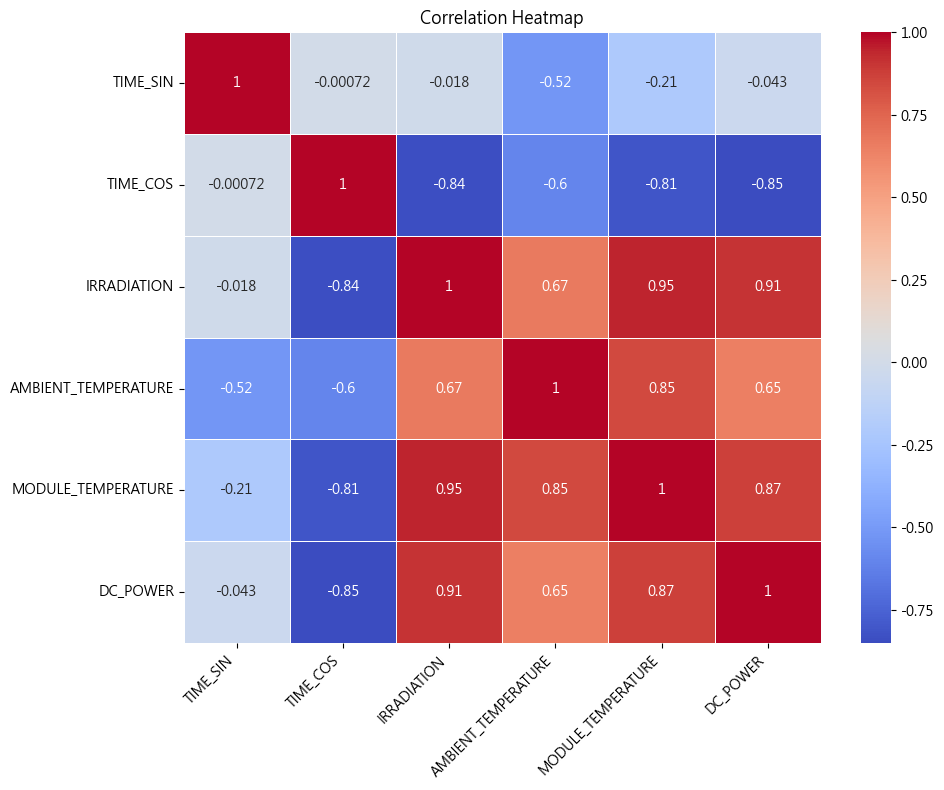

In [31]:
# numeric_columns = df_plant2.select_dtypes(include=np.number).columns.tolist() # 選取數值欄位
feature_columns = ['TIME_SIN', 'TIME_COS', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'DC_POWER']
corr_df = df_plant2[feature_columns].corr() # 計算相關係數矩陣 # numeric_columns
# mask = np.triu(np.ones_like(corr_df, dtype=bool), k=1) # 建立遮罩（只顯示下三角）
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', linewidths=0.5) # mask=mask
plt.title('Correlation Heatmap')
plt.xticks(rotation=45, horizontalalignment='right', fontsize=10)
plt.yticks(rotation=0, horizontalalignment='right', fontsize=10)
plt.tight_layout()
plt.savefig(r'.\預測結果圖\Plant2第二號發電機組\Correlation Heatmap.png')
plt.show()

In [32]:
corr_df['DC_POWER'].sort_values(ascending=False)

DC_POWER               1.000000
IRRADIATION            0.911708
MODULE_TEMPERATURE     0.872469
AMBIENT_TEMPERATURE    0.648327
TIME_SIN              -0.042747
TIME_COS              -0.849914
Name: DC_POWER, dtype: float64

<p> DC_POWER </p>

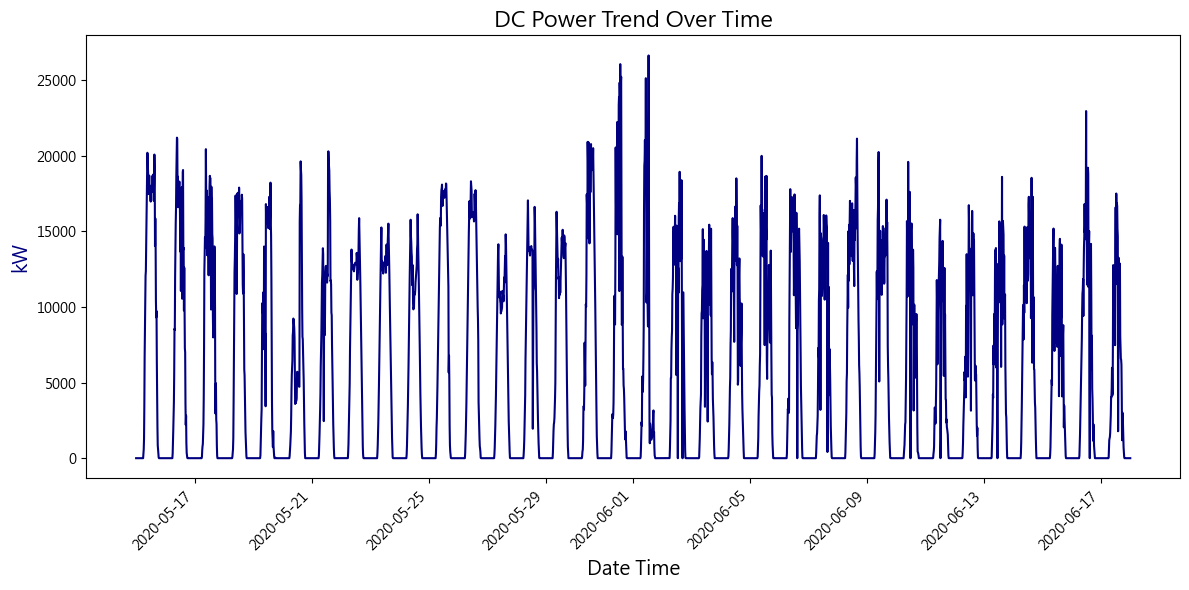

In [33]:
def DC_Trend_Over_Time(df_plant2):
    plt.figure(figsize=(12, 6))

    # Daily yield plot (Daily Yield 折線圖)，顯示整體發電趨勢。
    df_plant2['DC_POWER'].plot(color='navy') # 用 index 當作 x 軸（不需指定 x）
    plt.title('DC Power Trend Over Time', fontsize=16)
    plt.ylabel('kW', color='navy', fontsize=14)
    plt.xlabel('Date Time', fontsize=14)
    plt.xticks(rotation=45)
    plt.tick_params(axis='both', which='major', labelsize=10)
    plt.tight_layout()
    plt.savefig(r'.\預測結果圖\Plant2第二號發電機組\DC Power Trend Over Time.png')
    plt.show()

DC_Trend_Over_Time(df_plant2)

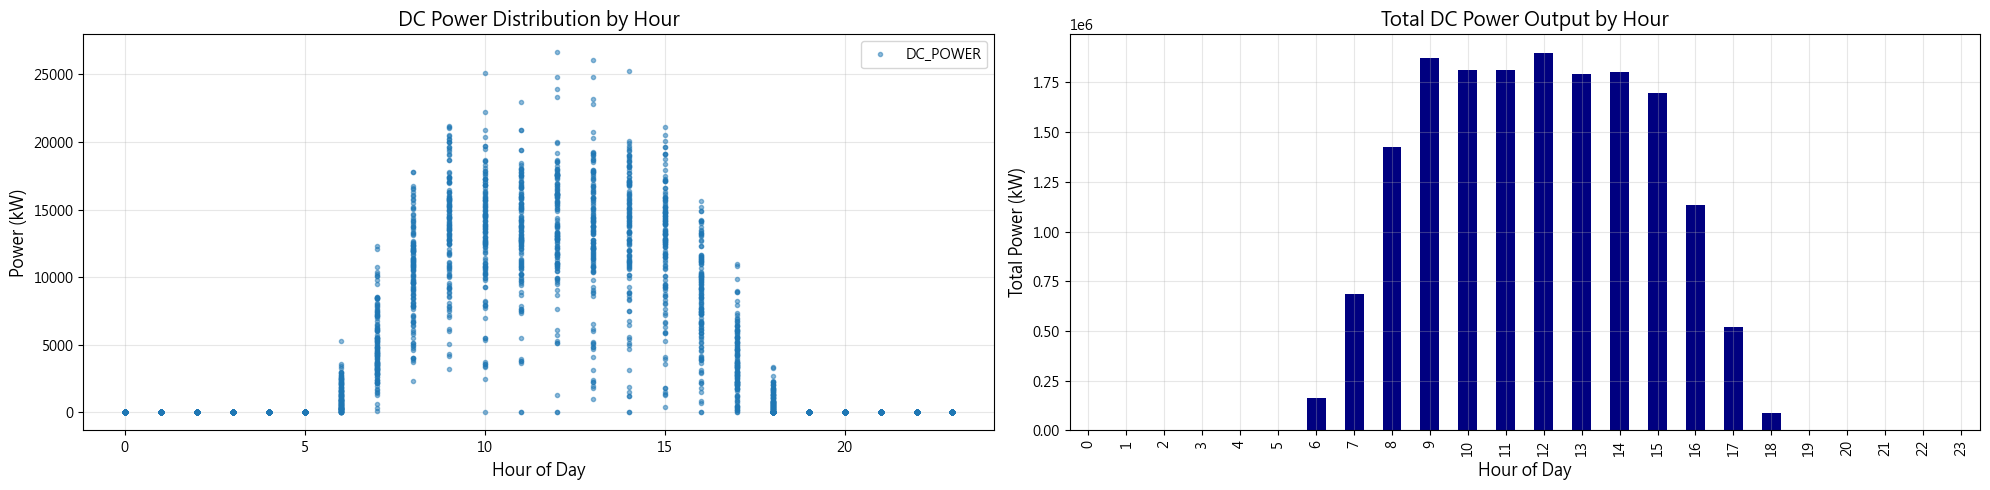

In [34]:
def DC_During_Hours(df_plant2):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(20, 5))

    # 左：散點圖
    ax1.plot(df_plant2['HOUR'], df_plant2['DC_POWER'], '.', alpha=0.5, label='DC_POWER')
    ax1.set_title('DC Power Distribution by Hour', fontsize=14)
    ax1.set_xlabel('Hour of Day', fontsize=12)
    ax1.set_ylabel('Power (kW)', fontsize=12)
    ax1.legend() # 圖例
    ax1.grid(True, alpha=0.3)

    # 右：長條圖（總功率）
    # 按照 HOUR 分組並計算DC_POWER功率
    hourly_sum = df_plant2.groupby('HOUR')['DC_POWER'].sum() # mean()
    hourly_sum.plot(kind='bar', color='navy', ax=ax2)
    ax2.set_title('Total DC Power Output by Hour', fontsize=14) # Average DC Power by Hour
    ax2.set_xlabel('Hour of Day', fontsize=12)
    ax2.set_ylabel('Total Power (kW)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(r'.\預測結果圖\Plant2第二號發電機組\DC Power by Hour.png')
    plt.show()

DC_During_Hours(df_plant2)

<p> Irradiation </p>

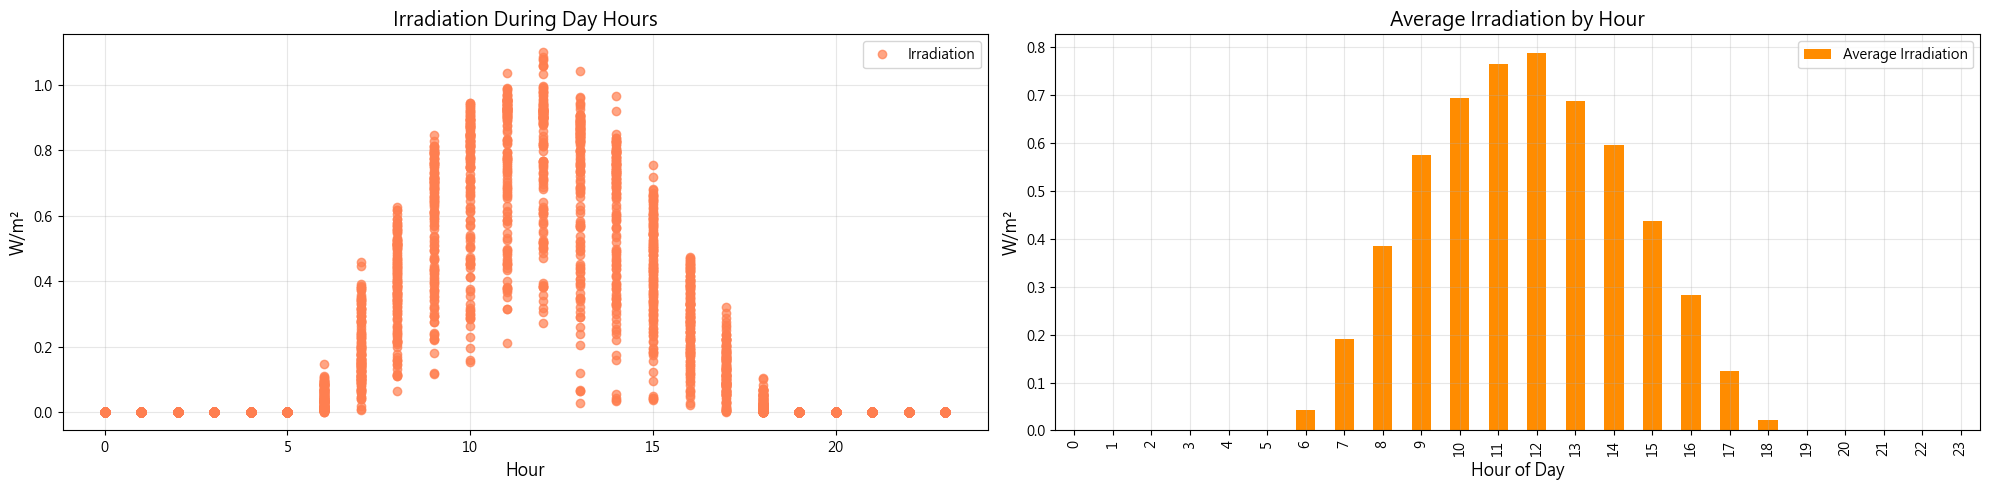

In [35]:
def Irradiation_By_Hour(df_plant2):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(20, 5))

    # 散點圖：光照量 vs 小時
    # 光照量（IRRADIATION） vs 時間（TIME），呈現一天內各時刻的光照強度分佈。
    df_plant2.plot(x='HOUR', y='IRRADIATION', ax=ax1, style='o', color='coral', alpha=0.7)
    ax1.set_title('Irradiation During Day Hours', fontsize=14)
    ax1.set_ylabel('W/m²', fontsize=12)
    ax1.set_xlabel('Hour', fontsize=12)
    ax1.tick_params(axis='both', which='major', labelsize=10)
    ax1.legend(['Irradiation'], fontsize=10)
    ax1.grid(alpha=0.3)

    # 長條圖：每小時平均光照量
    irradiation_by_hour = df_plant2.groupby('HOUR')['IRRADIATION'].mean() # 按照 HOUR 分組並計算IRRADIATION太陽日照
    irradiation_by_hour.plot(kind='bar', ax=ax2, color='darkorange')
    ax2.set_title('Average Irradiation by Hour', fontsize=14)
    ax2.set_ylabel('W/m²', fontsize=12)
    ax2.set_xlabel('Hour of Day', fontsize=12)
    ax2.tick_params(axis='both', labelsize=10)
    ax2.legend(['Average Irradiation'], fontsize=10)
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(r'.\預測結果圖\Plant2第二號發電機組\Irradiation by Hour.png')
    plt.show()

Irradiation_By_Hour(df_plant2)

temperature

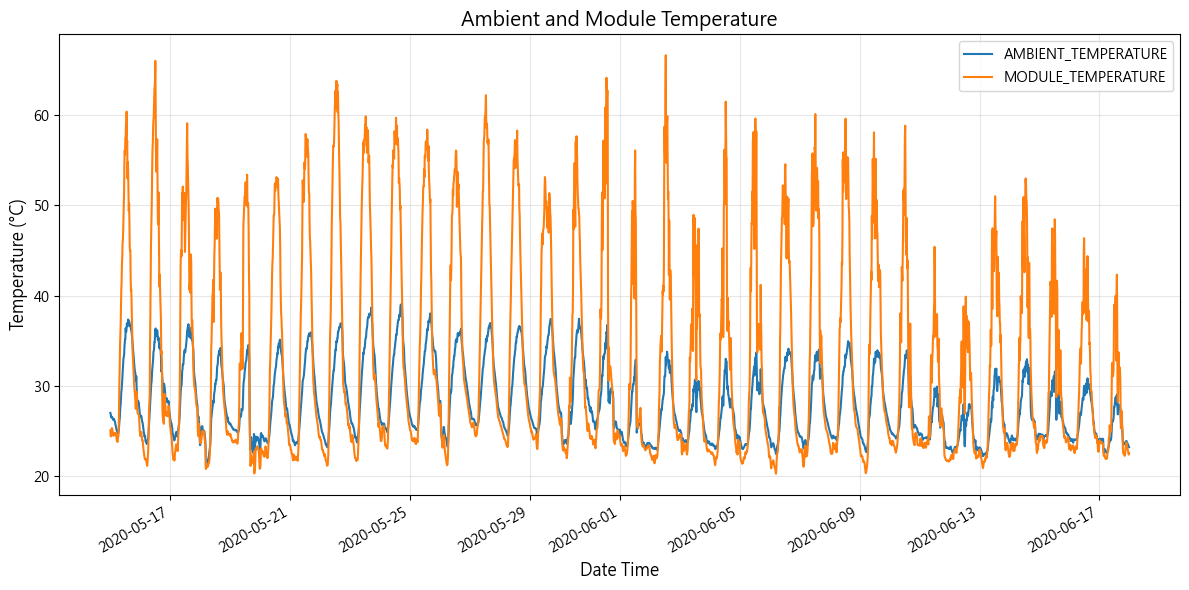

In [36]:
def plot_temperature(df_plant2):
    plt.figure(figsize=(12, 6))

    # 太陽能模組表面溫度 vs 環境氣溫。
    df_plant2[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']].plot(ax=plt.gca()) # (ax=plt.gca())
    plt.title('Ambient and Module Temperature', fontsize=14)
    plt.ylabel('Temperature (°C)', fontsize=12)
    plt.xlabel('Date Time', fontsize=12)
    plt.tick_params(axis='both', which='major', labelsize=10)
    plt.legend(fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(r'.\預測結果圖\Plant2第二號發電機組\Ambient and Module Temperature.png')
    plt.show()

plot_temperature(df_plant2)

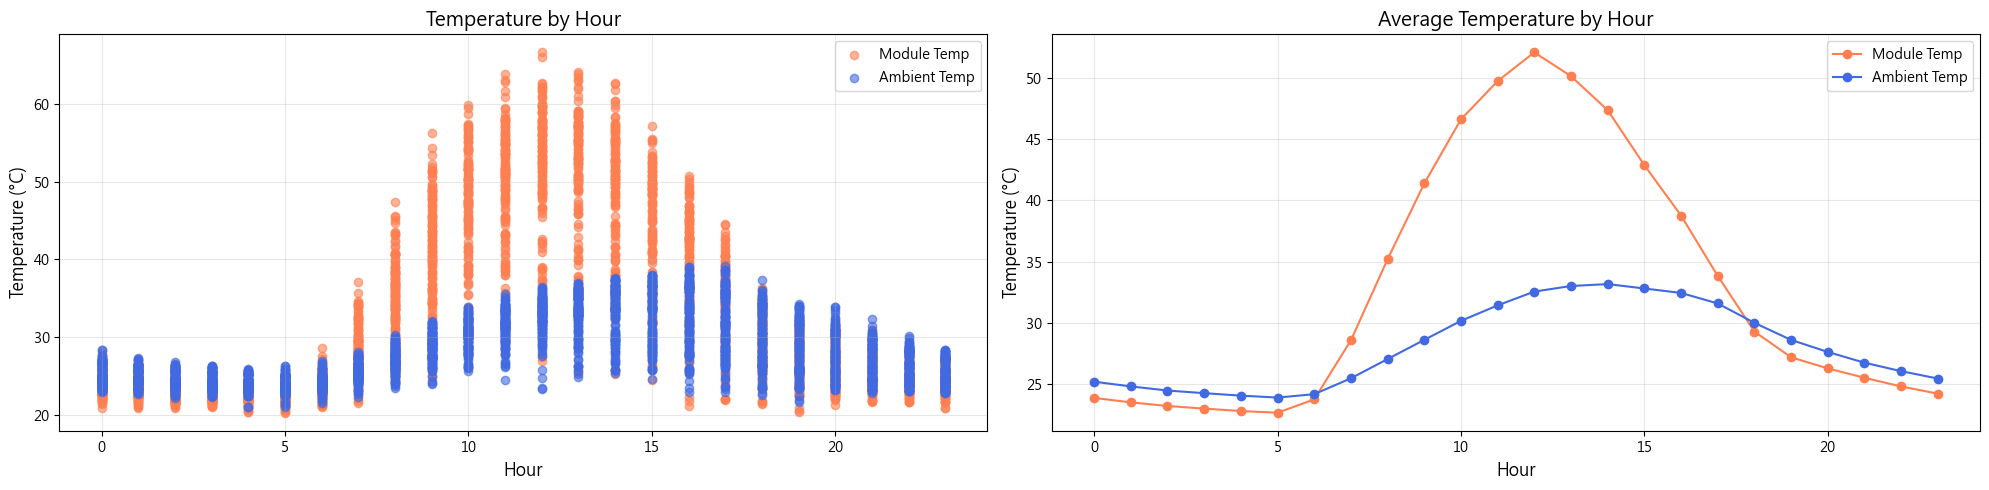

In [37]:
def temperature_during_DayHours(df_plant2):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(20, 5))

    # 左圖：散點圖
    ax1.scatter(df_plant2['HOUR'], df_plant2['MODULE_TEMPERATURE'], alpha=0.6, label='Module Temp',  color='coral')
    ax1.scatter(df_plant2['HOUR'], df_plant2['AMBIENT_TEMPERATURE'], alpha=0.6, label='Ambient Temp', color='royalblue')
    ax1.set_title('Temperature by Hour', fontsize=14)
    ax1.set_xlabel('Hour', fontsize=12)
    ax1.set_ylabel('Temperature (°C)', fontsize=12)
    ax1.grid(alpha=0.3)
    ax1.legend()

    # 右圖：趨勢圖
    avg_temp = df_plant2.groupby('HOUR')[['MODULE_TEMPERATURE', 'AMBIENT_TEMPERATURE']].mean()
    ax2.plot(avg_temp.index, avg_temp['MODULE_TEMPERATURE'], color='coral', label='Module Temp', marker='o')
    ax2.plot(avg_temp.index, avg_temp['AMBIENT_TEMPERATURE'], color='royalblue', label='Ambient Temp', marker='o')
    ax2.set_title('Average Temperature by Hour', fontsize=14)
    ax2.set_xlabel('Hour', fontsize=12)
    ax2.set_ylabel('Temperature (°C)', fontsize=12)
    ax2.grid(alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.savefig(r'.\預測結果圖\Plant2第二號發電機組\Temperature by Hour.png')
    plt.show()

temperature_during_DayHours(df_plant2)

In [38]:
# 繪製時間序列數據及其異常值（outliers）的函數。
def plot_outlier(ts, n_column, ewm_span=100, threshold=3.0):
    os.makedirs('feature', exist_ok=True) 
    '''
    利用 指數加權移動平均（EWMA） 來檢測異常。
    1.) ts：需要檢測異常值的時間序列資料，應該是 pandas.Series 型態。
    2.) n_column：圖表的標題，通常是欄位名稱，用來指明是哪個特徵（feature）。
    3.) ewm_span：控制指數加權移動平均的平滑度，越高的值使平滑效果越強（默認為 100）。
    4.) threshold：異常值的檢測閾值，以標準差為單位，默認為 3.0，即數值偏離均值超過 3 個標準差會被認為是異常值。
    '''
    assert type(ts) == pd.Series # 確保 ts 是一個 pandas.Series 型態，否則會報錯。
    fig, ax = plt.subplots(figsize=(15,5)) # 建立圖表，並設置圖表大小為 15x5。
    ewm_mean = ts.ewm(span=ewm_span).mean()  # 計算時間序列的指數加權移動平均值（EWMA）。
    ewm_std = ts.ewm(span=ewm_span).std()  # 計算時間序列的指數加權標準差，用來判斷異常值。
    ax.plot(ts, label='original') # 繪製原始時間序列數據。
    ax.plot(ewm_mean, label='ewma') # 繪製指數加權移動平均線，提供平滑的數據趨勢。

    # plot data which deviate from range during mean ±  3 * std as outlier 
    ax.fill_between(ts.index,
                    ewm_mean - ewm_std * threshold,
                    ewm_mean + ewm_std * threshold,
                    alpha=0.2) # 填充一個區域，範圍為平均值加減 3 倍標準差（可以根據 threshold 調整），用來表示「正常區域」。位於此區域外的數據將視為異常值。
    outlier = ts[(ts - ewm_mean).abs() > ewm_std * threshold] # 篩選出超出正常區域的異常值。
    ax.scatter(outlier.index, outlier, label='outlier') # 使用散點圖標記異常值的位置。
    ax.legend() # 添加圖例，標示出原始數據、移動平均線和異常值。
    plt.title(n_column) # 設置圖表標題為指定的欄位名稱（n_column）。
    plt.savefig(f'feature/{n_column}.png') # 儲存圖表

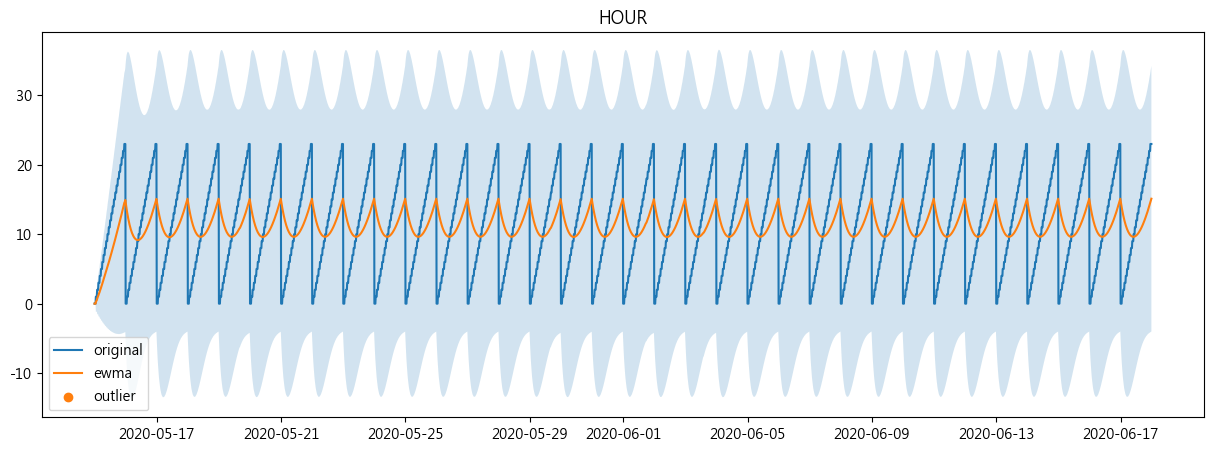

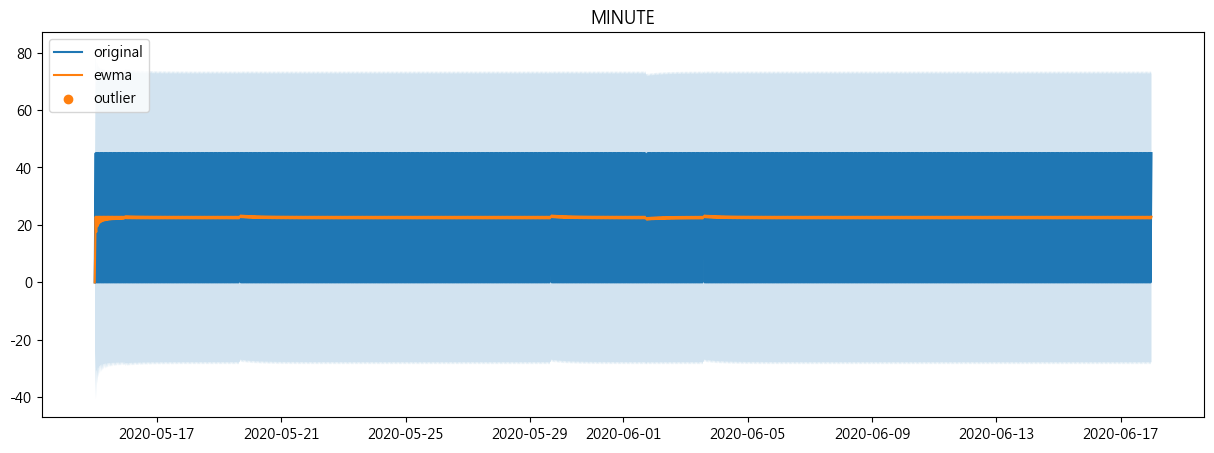

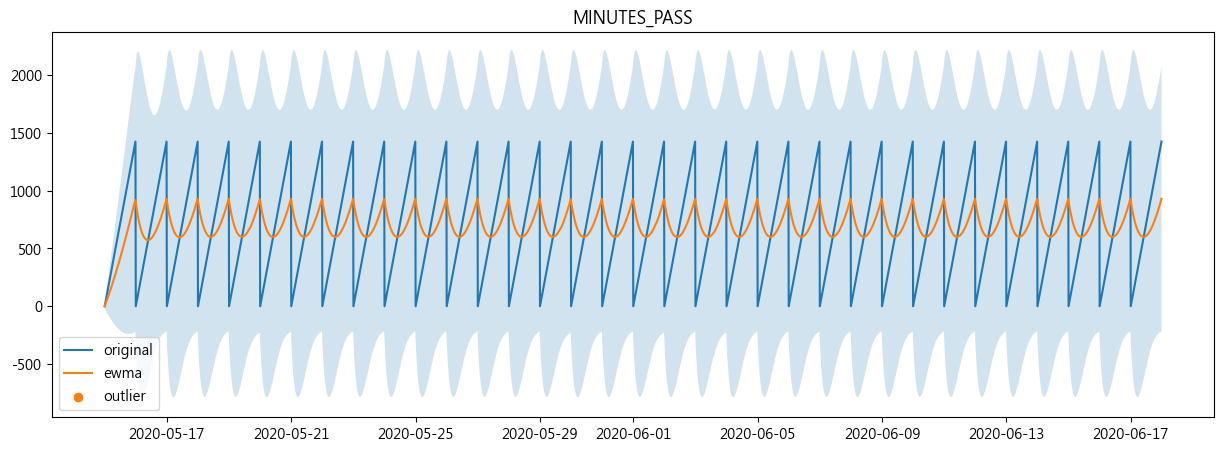

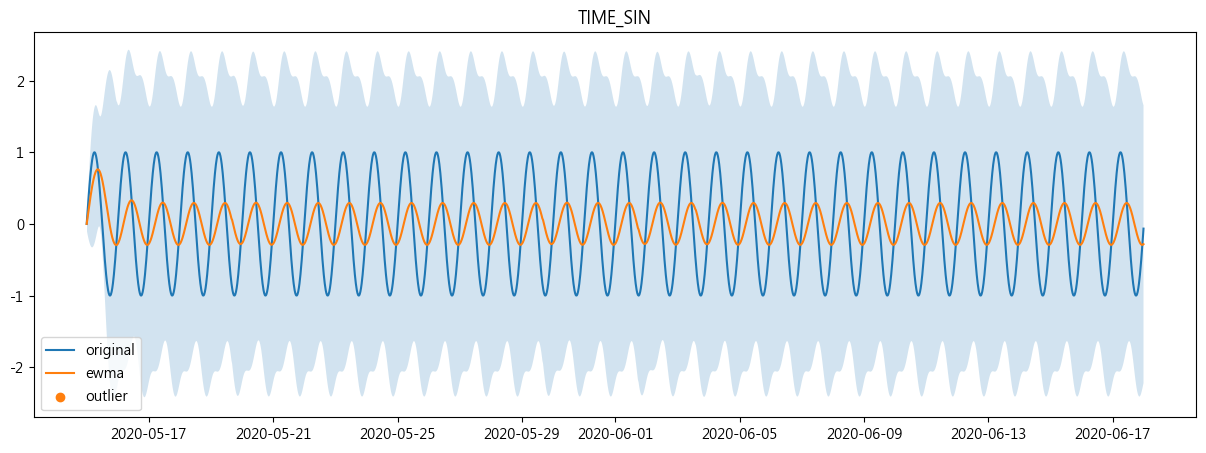

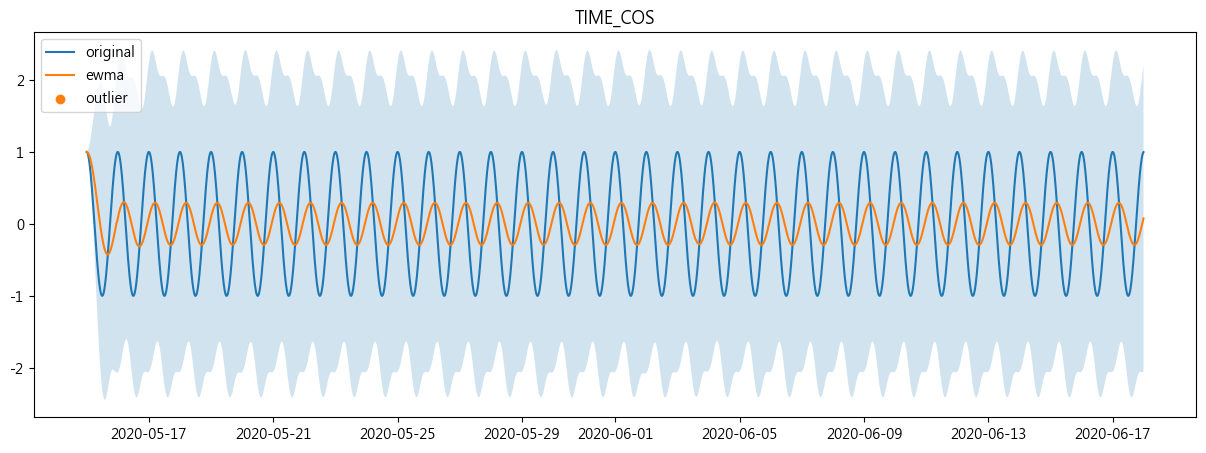

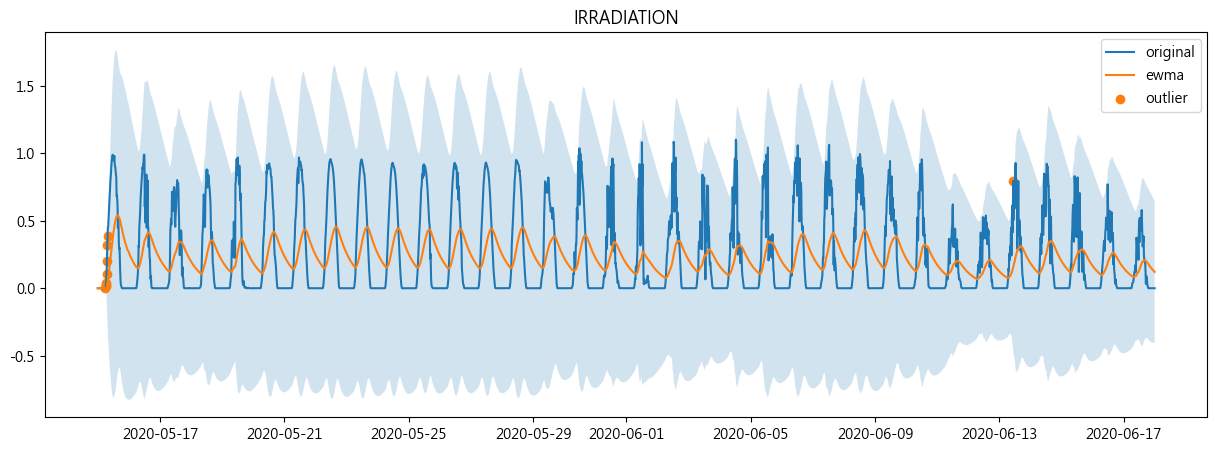

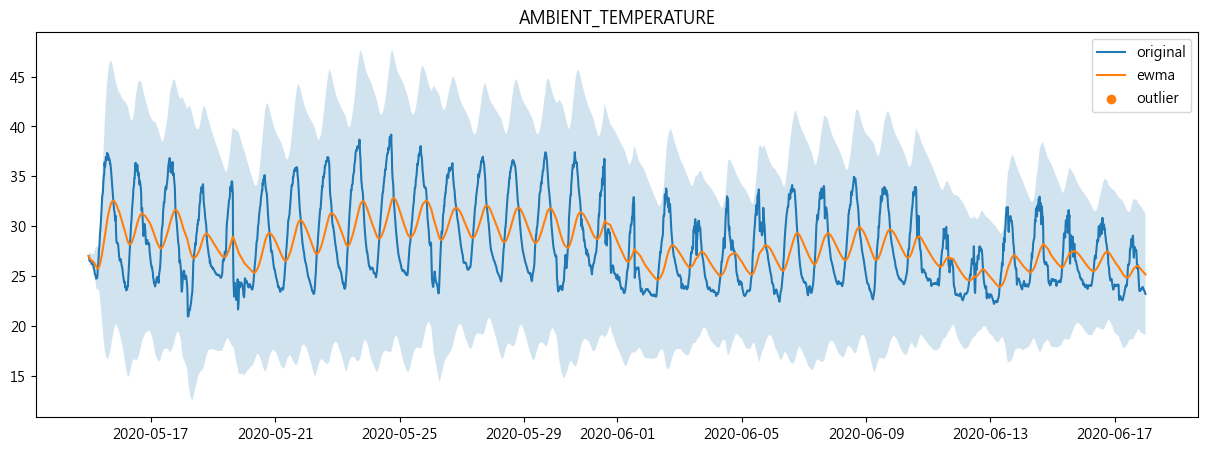

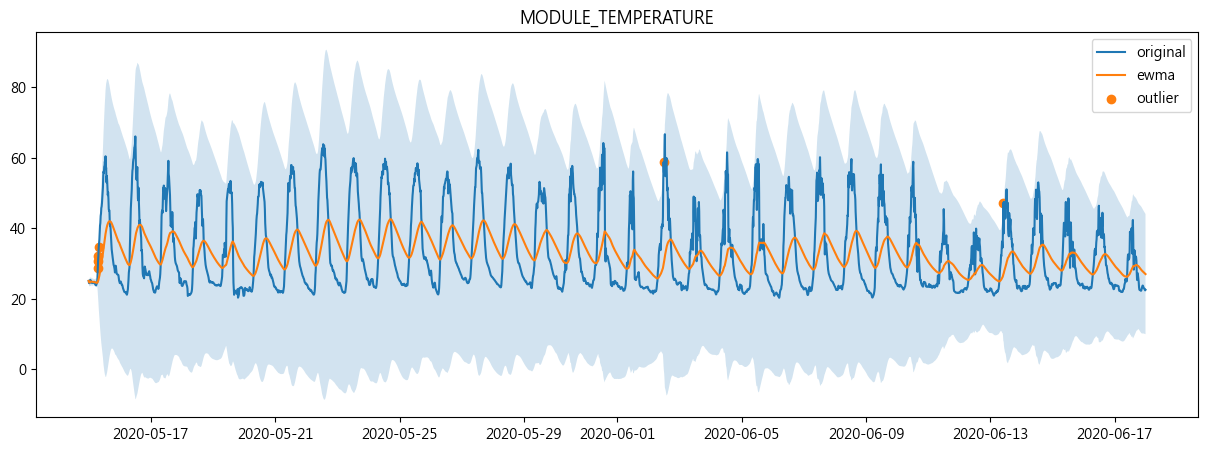

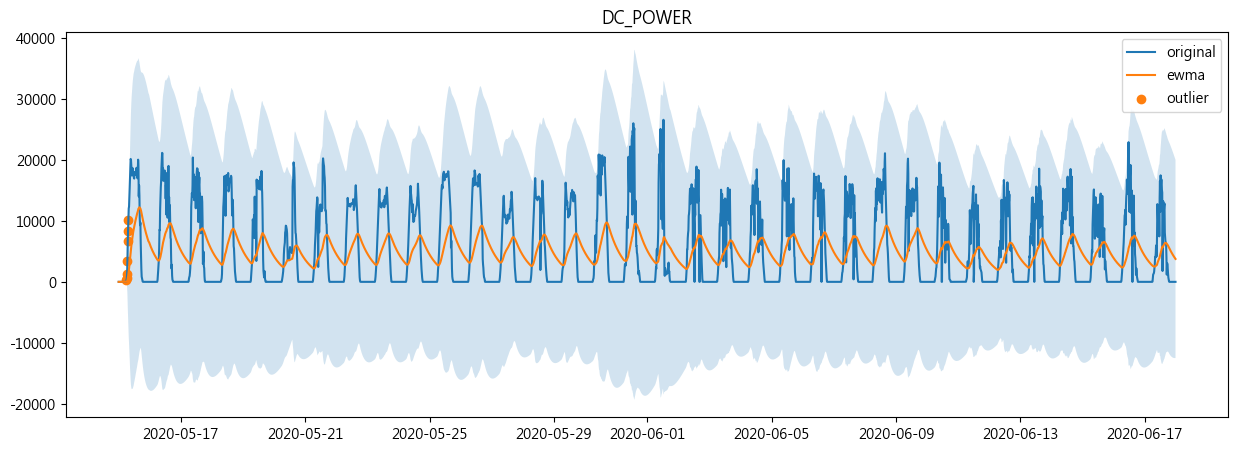

In [39]:
# save feature plot 
for n_column in df_plant2.columns:
    plot_outlier(df_plant2[n_column], n_column)

<h4 style='color:blue'> Feature Importance 特徵重要性 </h4>

<p> train_test_split 切分資料 </p>

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

In [41]:
target_col = 'DC_POWER' # 'AC_POWER'
# feature_cols = [col for col in df_plant2.columns if col not in [target_col]] # ['TIME', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']
feature_cols = ['TIME_SIN', 'TIME_COS', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']
feature_cols

['TIME_SIN',
 'TIME_COS',
 'IRRADIATION',
 'AMBIENT_TEMPERATURE',
 'MODULE_TEMPERATURE']

In [42]:
# 製作 X 和 y
X = df_plant2[feature_cols]
y = df_plant2[target_col]

# 切分資料
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

<p style='color:blue'> Random Forest 進行分析 </p>
以原樣餵入 Random Forest，不用再進行 scaler 處理，反而能更直觀觀察效果差異。

In [43]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

importances = rf.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
2,IRRADIATION,0.935725
4,MODULE_TEMPERATURE,0.024299
3,AMBIENT_TEMPERATURE,0.022647
0,TIME_SIN,0.010471
1,TIME_COS,0.006858


C:\Users\HoChePing\AppData\Local\Temp\ipykernel_28000\2270556309.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis') # 使用色彩分層突顯重要性


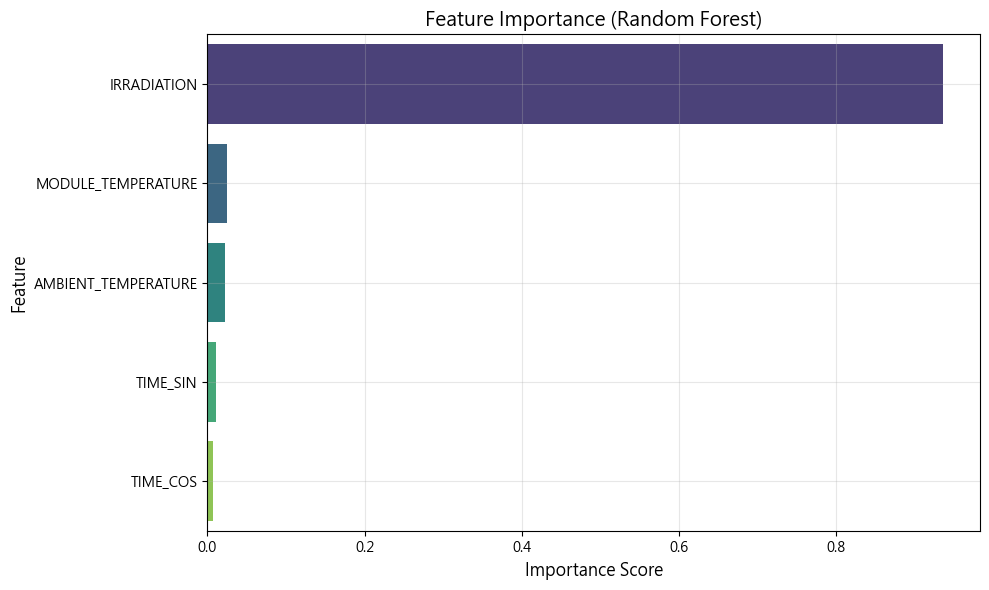

In [44]:
feature_importance = feature_importance.sort_values(by='Importance', ascending=False) # 排序

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis') # 使用色彩分層突顯重要性

plt.title('Feature Importance (Random Forest)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(r'.\預測結果圖\Plant2第二號發電機組\Feature Importance (Random Forest).png')
plt.show()

<p> Permutation Importance（特徵擾動重要性）=> 原理：逐一打亂每個特徵，觀察模型性能下降程度。</p>

In [45]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
result = permutation_importance(model, X_val, y_val, n_repeats=10, random_state=42)
importance = pd.DataFrame({'feature': feature_cols, 'importance': result.importances_mean})
importance.sort_values(by='importance', ascending=False)

,feature,importance
2,IRRADIATION,1.777483
3,AMBIENT_TEMPERATURE,0.013088
0,TIME_SIN,0.004525
4,MODULE_TEMPERATURE,0.001172
1,TIME_COS,-0.000035


<p style='color:blue'> Lasso 進行分析 => 讓某些不重要的特徵係數變成 0（即直接剔除）。 </p>

<p> 本分析使用 Lasso 作為一種線性模型基礎上的特徵篩選，僅供對資料集結構之初步了解，後續仍以非線性模型如 LSTM/xLSTM 為主進行建模與重要性評估。 </p>

In [46]:
# 預測目標欄位
target_col = 'DC_POWER' # 'AC_POWER'
# feature_cols = [col for col in df_plant2.columns if col not in [target_col, 'DATE_TIME']]  # ['TIME', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION'] 
feature_cols = ['TIME_SIN', 'TIME_COS', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']
feature_cols

['TIME_SIN',
 'TIME_COS',
 'IRRADIATION',
 'AMBIENT_TEMPERATURE',
 'MODULE_TEMPERATURE']

In [47]:
# 分離 X 和 y
X = df_plant2[feature_cols].values
y = df_plant2[target_col].values.reshape(-1, 1)

In [48]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

# 標準化
x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_scaled = x_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y).ravel()  # 需降維為一維陣列

In [49]:
# 建立 Lasso 模型
model = Lasso(alpha=0.001)
model.fit(X_scaled, y_scaled)

# 抓取特徵名稱與權重
coeff = pd.Series(model.coef_, index=feature_cols)
coeff = coeff.sort_values(ascending=False)
coeff

IRRADIATION            0.800014
AMBIENT_TEMPERATURE    0.134758
TIME_SIN              -0.005363
MODULE_TEMPERATURE    -0.226422
TIME_COS              -0.279518
dtype: float64

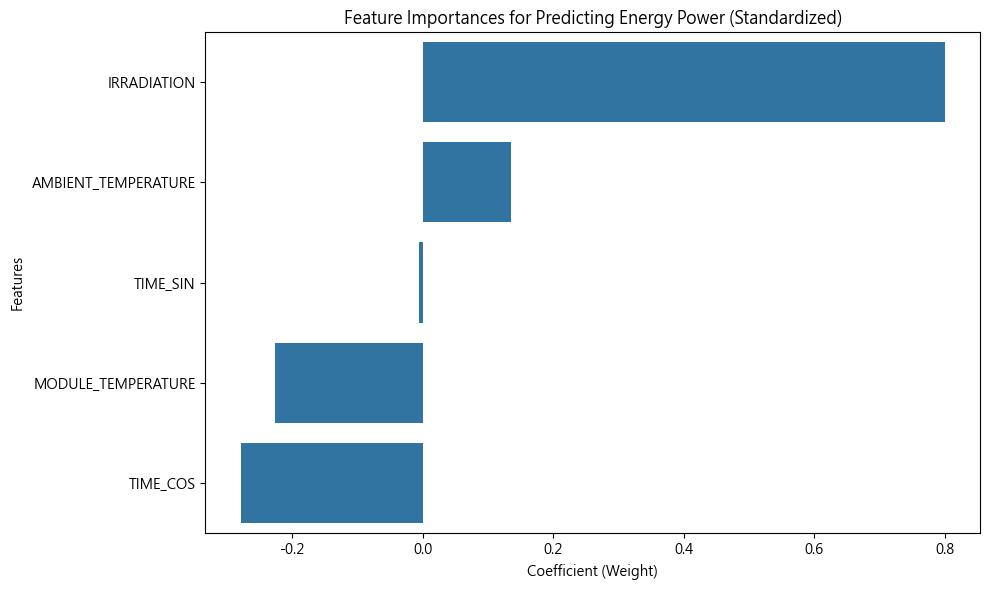

In [50]:
# 繪圖
plt.figure(figsize=(10, 6))
sns.barplot(x=coeff, y=coeff.index)
plt.title('Feature Importances for Predicting Energy Power (Standardized)')
plt.xlabel('Coefficient (Weight)')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig(r'.\預測結果圖\Plant2第二號發電機組\Feature Importance (Lasso).png')
plt.show()

<h3 style='color:blue'> 資料前處理 </h3>

<h4> 辨別「白天/晚上時間區間」 </h4>

In [51]:
# df_plant2['TIME'] = df_plant2.index.time
# df_plant2 = df_plant2.groupby('TIME')[['DC_POWER']].sum().reset_index()
# pd.set_option('display.max_rows', None)
# df_plant2

In [52]:
# df_plant2['TIME'] = df_plant2.index.time
# df_plant2.to_csv('LSTM Prediction_plant2.csv')

| 類別 | 時間範圍                    |
| -- | ----------------------- |
| 白天 | 05:45:00 ～ 18:45:00     |
| 晚上 | 19:00:00 ～ 05:30:00（次日） |


<p> 使用 .resample('15T') 重新補齊缺漏的時間戳記 </p>

In [53]:
# 這裡只是要補時間點，因此使用 asfreq() 或 keep NaN
df_plant2 = df_plant2.resample('15T').asfreq()
df_plant2 = encode_time_features(df_plant2) # Time 分離出時間
df_plant2

C:\Users\HoChePing\AppData\Local\Temp\ipykernel_28000\966090559.py:2: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_plant2 = df_plant2.resample('15T').asfreq()


,HOUR,MINUTE,MINUTES_PASS,TIME_SIN,TIME_COS,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,DC_POWER
DATE_TIME,,,,,,,,,
2020-05-15 00:00:00,0,0,0,0.000000,1.000000,0.0,27.004764,25.060789,0.0
2020-05-15 00:15:00,0,15,15,0.065403,0.997859,0.0,26.880811,24.421869,0.0
2020-05-15 00:30:00,0,30,30,0.130526,0.991445,0.0,26.682055,24.427290,0.0
2020-05-15 00:45:00,0,45,45,0.195090,0.980785,0.0,26.500589,24.420678,0.0
2020-05-15 01:00:00,1,0,60,0.258819,0.965926,0.0,26.596148,25.088210,0.0
...,...,...,...,...,...,...,...,...,...
2020-06-17 22:45:00,22,45,1365,-0.321439,0.946930,0.0,23.511703,22.856201,0.0
2020-06-17 23:00:00,23,0,1380,-0.258819,0.965926,0.0,23.482282,22.744190,0.0
2020-06-17 23:15:00,23,15,1395,-0.195090,0.980785,0.0,23.354743,22.492245,0.0


In [54]:
df_plant2.isnull().sum()

HOUR                   0
MINUTE                 0
MINUTES_PASS           0
TIME_SIN               0
TIME_COS               0
IRRADIATION            5
AMBIENT_TEMPERATURE    5
MODULE_TEMPERATURE     5
DC_POWER               5
dtype: int64

選擇性補值

先填補氣象數據

In [55]:
env_cols = ['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION'] # 氣象欄位(溫度)

df_plant2[env_cols] = (
    df_plant2[env_cols]
    .interpolate(method='time') # 插補為主：根據時間推估缺值
    .fillna(method='ffill') # 前向補值備援（處理開頭）
    .fillna(method='bfill') # 後向補值備援（處理結尾）
)

C:\Users\HoChePing\AppData\Local\Temp\ipykernel_28000\2098485603.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_plant2[env_cols]


再填補發電資料(DC_POWER)

In [56]:
 # 加上 Day/Night 標籤
df_plant2['day_night'] = df_plant2.index.map(classify_day_night)

# 夜晚 → 缺失補 0
df_plant2.loc[(df_plant2['day_night'] == 'Night') & (df_plant2['DC_POWER'].isna()), 'DC_POWER'] = 0 

# 白天 → 缺失補插值
df_plant2.loc[df_plant2['day_night'] == 'Daytime', 'DC_POWER'] = (
    df_plant2.loc[df_plant2['day_night'] == 'Daytime', 'DC_POWER'].interpolate(method='time')
)

In [57]:
df_plant2.drop(columns=['day_night'], inplace=True)

In [58]:
df_plant2.isnull().sum()

HOUR                   0
MINUTE                 0
MINUTES_PASS           0
TIME_SIN               0
TIME_COS               0
IRRADIATION            0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
DC_POWER               0
dtype: int64

<h3 style='color:blue'> Scaler 標準化 </h3>

<ol> StandardScaler vs MinMaxScaler
    <li> StandardScaler => 將數據轉為平均值為 0、標準差為 1；中心化、會忽略最小最大值的意義。 </li>
    <li> MinMaxScaler => 將數據縮放至 [0, 1] 範圍；保留原本極小與極大值比例，不會扭曲數據結構。 </li>
</ol>

<ol> 各欄位的Scaler方式
    <li style='color:red'> TIME_SIN, TIME_COS => 不需再標準化，值本身已落在 [-1, 1] </li>
    <li> MINUTES_PASS => 不建議 同時使用 MINUTES_PASS 和 TIME_SIN / TIME_COS 作為 LSTM 模型的特徵輸入，會造成資訊重複（collinearity），讓模型混淆，造成不穩定學習，因此刪除HOUR, MINUTE, MINUTES_PASS欄位。 </li>
    <li> HOUR, MINUTE => 不建議直接使用，且TIME_SIN, TIME_COS 已經存在，就可以 完全捨棄 HOUR、MINUTE（它們的資訊已被 sin/cos 包含） </li>
    <li style='color:red'> MODULE_TEMPERATURE =>  太陽能板的面板溫度，範圍落在18~65，趨勢較劇烈波動，使用 MinMaxScaler()。 </li>
    <li style='color:green'> MODULE_TEMPERATURE在日照強時會急遽上升至 60°C 以上，一旦日落會快速掉回 20°C 左右，這種「快速上升／下降的波形」，類似太陽能功率曲線（如 DC_POWER）。 </li>
    <li style='color:red'> IRRADIATION => 光照強度，是影響發電量（DC_POWER）最直接的氣象因子。呈現對稱鐘形分布，高峰落在中午（10:00–13:00）。使用 MinMaxScaler()。 </li>
    <li style='color:green'> MODULE_TEMPERATUR、IRRADIATION => 同樣屬於光照驅動變數，建議統一處理方式，使用 MinMaxScaler()。 </li>
    <li style='color:green'> 使用 StandardScaler() 會將高峰值「去中心化」，模型可能學不到中午是最強發電時段。 </li>
    <li style='color:red'> DC_POWER => 太陽能板產生的直流功率，使用 MinMaxScaler()。 </li>
</ol>

| 特徵欄位                   | 描述說明                         | Scaler 建議          | 說明理由                                       |
|----------------------------|----------------------------------|----------------------|------------------------------------------------|
| `TIME_SIN`, `TIME_COS`     | 時間週期性特徵（一天內位置）              | ❌ 不需標準化         | Sin/Cos 原本就落在 \[-1, 1]，不需再正規化             |
| `MODULE_TEMPERATURE`       | 太陽能板面板溫度，範圍約 18–65°C         | ✅ `MinMaxScaler()` | 劇烈波動，建議壓縮到 \[0, 1]，利於模型收斂               |
| `IRRADIATION`              | 太陽輻射量，呈鐘形分布，高峰落在上午10–13時 | ✅ `MinMaxScaler()` | 與發電強烈正相關，值範圍有限且無負值，適合 MinMax 壓縮   |
| `DC_POWER`                 | 預測目標：太陽能板產生的直流功率           | ✅ `MinMaxScaler()` | 輸出值非負且最大值遠大，建議壓縮以穩定模型訓練             |


| 欄位名            | 原因                         |
| -------------- | -------------------------- |
| `HOUR`         | 可被 `TIME_SIN/COS` 完全取代     |
| `MINUTE`       | 時間粒度太細，與 `TIME_SIN/COS` 重複 |
| `MINUTES_PASS` | 只作為週期轉換的中介，不需保留            |


~~AMBIENT_TEMPERATURE => 廠區環境溫度，範圍落在20~35，趨勢較緩變、穩定，使用 StandardScaler()。~~
   
 ↑ 這點我無法確定！

In [59]:
from sklearn.preprocessing import MinMaxScaler

In [60]:
df_plant2.drop(columns=['HOUR', 'MINUTE', 'MINUTES_PASS'], inplace=True)
df_plant2.columns

Index(['TIME_SIN', 'TIME_COS', 'IRRADIATION', 'AMBIENT_TEMPERATURE',
       'MODULE_TEMPERATURE', 'DC_POWER'],
      dtype='object')

In [61]:
# 預測目標欄位
target_col = 'DC_POWER' 
cyclic_cols = ['TIME_SIN', 'TIME_COS'] # 不進行標準化
scaler_cols = ['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE'] # 建議使用 MinMaxScaler

In [62]:
# 建立 scaler 並 fit_transform 特徵欄位
feature_scaler = MinMaxScaler() # 將數據縮放到一個固定範圍內（例如 [0, 1]）。
df_plant2[scaler_cols] = feature_scaler.fit_transform(df_plant2[scaler_cols]) # 正規化數據

# 處理目標變數
target_scaler = MinMaxScaler() # 將數據縮放到一個固定範圍內（例如 [0, 1]）。
df_plant2[target_col] = target_scaler.fit_transform(df_plant2[[target_col]]) # 正規化數據

df_plant2

,TIME_SIN,TIME_COS,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,DC_POWER
DATE_TIME,,,,,,
2020-05-15 00:00:00,0.000000,1.000000,0.0,0.332381,0.103420,0.0
2020-05-15 00:15:00,0.065403,0.997859,0.0,0.325585,0.089641,0.0
2020-05-15 00:30:00,0.130526,0.991445,0.0,0.314688,0.089758,0.0
2020-05-15 00:45:00,0.195090,0.980785,0.0,0.304739,0.089616,0.0
2020-05-15 01:00:00,0.258819,0.965926,0.0,0.309978,0.104011,0.0
...,...,...,...,...,...,...
2020-06-17 22:45:00,-0.321439,0.946930,0.0,0.140868,0.055877,0.0
2020-06-17 23:00:00,-0.258819,0.965926,0.0,0.139254,0.053462,0.0
2020-06-17 23:15:00,-0.195090,0.980785,0.0,0.132262,0.048029,0.0


<h4 style="color:blue"> 拆分資料 & Save Dataset </h4>

In [63]:
df_plant2.to_csv(r'Merged plant2 Data.csv')

In [64]:
y = df_plant2['DC_POWER'].values
pd.DataFrame(y, columns=['DC_POWER'], index=df_plant2.index)

,DC_POWER
DATE_TIME,
2020-05-15 00:00:00,0.0
2020-05-15 00:15:00,0.0
2020-05-15 00:30:00,0.0
2020-05-15 00:45:00,0.0
2020-05-15 01:00:00,0.0
...,...
2020-06-17 22:45:00,0.0
2020-06-17 23:00:00,0.0
2020-06-17 23:15:00,0.0


In [65]:
X = df_plant2.drop(['DC_POWER'], axis=1).values
pd.DataFrame(X, columns=df_plant2.columns[:-1], index=df_plant2.index)

,TIME_SIN,TIME_COS,IRRADIATION,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE
DATE_TIME,,,,,
2020-05-15 00:00:00,0.000000,1.000000,0.0,0.332381,0.103420
2020-05-15 00:15:00,0.065403,0.997859,0.0,0.325585,0.089641
2020-05-15 00:30:00,0.130526,0.991445,0.0,0.314688,0.089758
2020-05-15 00:45:00,0.195090,0.980785,0.0,0.304739,0.089616
2020-05-15 01:00:00,0.258819,0.965926,0.0,0.309978,0.104011
...,...,...,...,...,...
2020-06-17 22:45:00,-0.321439,0.946930,0.0,0.140868,0.055877
2020-06-17 23:00:00,-0.258819,0.965926,0.0,0.139254,0.053462
2020-06-17 23:15:00,-0.195090,0.980785,0.0,0.132262,0.048029


<h5 style='color:blue'> 20%：訓練、80%：測試 </h5>

In [66]:
# 資料拆分比例
# 取前面20%為train，後面80%為test。
split_index = int(len(df_plant2) * 0.2)
split_index

652

In [67]:
# 時間序列切分（避免 shuffle）
X_train = X[:split_index] # 僅使用前 20% 做 fine-tune
y_train = y[:split_index]
X_test = X[split_index:] # 後 80% 當作測試集
y_test = y[split_index:]

In [68]:
# 儲存為 pkl
data_dic = {
    'X_train': X_train,
    'y_train': y_train,
    'X_test': X_test,
    'y_test': y_test,
}

# pkl檔案 用於儲存 Python 資料結構。
folder_name = "20%Training & 80%Testing"
os.makedirs(folder_name, exist_ok=True)
# pkl檔案 用於儲存 Python 資料結構。
for key, value in data_dic.items():
    file_path = os.path.join(folder_name, f"{key}.pkl")
    with open(file_path, 'wb') as f: # 使用 pickle.dump 將數據寫入文件，'wb' 表示二進制寫入。
        pickle.dump(value, f)
    print(f"已儲存：{file_path}")

已儲存：20%Training & 80%Testing\X_train.pkl
已儲存：20%Training & 80%Testing\y_train.pkl
已儲存：20%Training & 80%Testing\X_test.pkl
已儲存：20%Training & 80%Testing\y_test.pkl


In [69]:
len(X_train), len(y_train), len(X_test), len(y_test)

(652, 652, 2612, 2612)

<h5 style='color:blue'> 80%：訓練、20%：測試 </h5>

In [70]:
# 資料拆分比例
# 取前面80%為train，後面20%為test。
split_index = int(len(df_plant2) * 0.8)
split_index

2611

In [71]:
# 時間序列切分（避免 shuffle）
X_train = X[:split_index]
y_train = y[:split_index]
X_test = X[split_index:]
y_test = y[split_index:]

In [72]:
# 儲存為 pkl
data_dic = {
    'X_train': X_train,
    'y_train': y_train,
    'X_test': X_test,
    'y_test': y_test,
}

# pkl檔案 用於儲存 Python 資料結構。
folder_name = "80%Training & 20%Testing"
os.makedirs(folder_name, exist_ok=True)
for key, value in data_dic.items():
    file_path = os.path.join(folder_name, f"{key}.pkl")
    with open(file_path, 'wb') as f: # 使用 pickle.dump 將數據寫入文件，'wb' 表示二進制寫入。
        pickle.dump(value, f)
    print(f"已儲存：{file_path}")

已儲存：80%Training & 20%Testing\X_train.pkl
已儲存：80%Training & 20%Testing\y_train.pkl
已儲存：80%Training & 20%Testing\X_test.pkl
已儲存：80%Training & 20%Testing\y_test.pkl


In [73]:
len(X_train), len(y_train), len(X_test), len(y_test)

(2611, 2611, 653, 653)

<h2> LSTM模型預測 </h2>

<ol>
    <li> 使用前 60 分鐘的數據作為輸入 (X 陣列)，並以第75分鐘的DAILY_YIELD數據作為對應的輸出。 </li>
    <li> 此方法採用滑動視窗（sliding window）的方式，持續向前移動視窗，讓模型學習隨時間變化的規律，從而能夠預測未來的時間區間內的產能變化。 </li>
</ol>

In [74]:
#  Tensorflow imports
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError as RMSE, mean_squared_error as mse, mean_absolute_error as mae
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LSTM, Dense, InputLayer, Dropout
from tensorflow.keras.layers import TimeDistributed
from tensorflow.keras import initializers, regularizers # initializers → 初始化層的權重、regularizers → 對權重加入 L1/L2 正則化
from tensorflow.keras.utils import plot_model

from sklearn.metrics import r2_score

<h3> definition 函式庫 </h3>

In [75]:
#將時間序列數據轉換為適合LSTM訓練的輸入特徵 (X) 和標籤 (y)
def Sliding_Window(df, feature_cols, target_col='DC_POWER', window_size=5):  
    '''
    用每 5 個連續數據點預測下一個數據點（即前60分鐘的5組特徵，預測未來第75分鐘的發電量。）
    將時間序列數據轉換為 LSTM 所需的格式：
    X shape → (樣本數, 時間步長, 特徵數)
    y shape → (樣本數, 特徵數)
    '''
    X = []
    y = []
    feature_values = df[feature_cols].to_numpy()
    target_values = df[[target_col]].to_numpy()
    
    for i in range(len(df)-window_size): # 用長度為 window_size（預設 5）的小段序列當作輸入X，用下一個時間點的值作為預測目標y。
        X.append(feature_values[i:i+window_size]) # shape: (5, 特徵數)
        y.append(target_values[i+window_size]) # shape: (1,)
        
    return np.array(X), np.array(y)

In [76]:
def save_lr_curve(H, f_name=None):
    """
    save learning curve in deep learning

    Args:
        model : trained model (keras)
        out_dir (str): directory path for saving
    """
    f_name = 'Learning Curve' if not f_name else f'{f_name} Learning Curve' # 檔名
    plt.figure(figsize=(30, 10)) # 建立圖表
    plt.rcParams["font.size"] = 18 # 字體大小為 18。
    plt.plot(H.history['loss'], label='Train', marker='o', markersize=5) # 繪製訓練損失曲線
    plt.plot(H.history['val_loss'], label='Validation', marker='s', markersize=5) # 繪製驗證損失曲線
    # Add value annotations
    for i, value in enumerate(H.history['loss']):
        if i % 10 == 0:  # 每隔 10 個數據點標一次
            plt.annotate(f'{value:.4f}', xy=(i, value), xytext=(0, 5), textcoords='offset points', ha='center', va='bottom', fontsize=12, color='blue', alpha=0.9)
    for i, value in enumerate(H.history['val_loss']):
        if i % 10 == 0:  # 每隔 10 個數據點標一次
            plt.annotate(f'{value:.4f}', xy=(i, value), xytext=(0, -5), textcoords='offset points', ha='center', va='top', fontsize=12, color='orange', alpha=0.9)
    plt.title(f'{f_name} (Model Loss)', fontsize=18)
    plt.ylabel('Loss', fontsize=16)
    plt.xlabel('Epoch', fontsize=16)
    plt.legend(['Train', 'Validation'], loc='best', fontsize=14)
    plt.grid(alpha=0.3)  # 加入透明網格，便於觀察
    plt.tight_layout()
    plt.savefig(f".\預測結果圖\Plant2第二號發電機組\{f_name}.png", bbox_inches="tight")
    plt.show()
    # plt.close('all')  # 關閉所有繪圖對象
    print(f"Plot saved to .\預測結果圖\Plant2第二號發電機組\{f_name}.png")

In [77]:
def metric_score(y_test_time: np.array, y_pred_test_time: np.array, model=None):
    """
    save mean squared error for tareget variable

    Args:
        y_test_time (np.array): observed data for target variable # 實際值
        y_pred_test_time (np.array): predicted data for target variable # 預測值
        out_dir (str): directory path for saving # 保存目錄
        model : trained model (keras)
    """
    # sklearn
    mse_loss = mse(y_test_time, y_pred_test_time) # 計算均方誤差
    rmse_loss = np.sqrt(mse_loss)  # RMSE
    mae_loss = mae(y_test_time, y_pred_test_time) # 計算平均絕對誤差
    r2 = r2_score(y_test_time, y_pred_test_time)  # R-squared指標，反映模型解釋目標變數變異程度的能力。

    # Printing metrics
    print(f"Mean Squared Error (MSE): {mse_loss:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse_loss:.4f}")
    print(f"Mean Absolute Error (MAE): {mae_loss:.4f}")
    print(f"R² Score: {r2:.4f}")

    with open(r'.\預測結果圖\Plant2第二號發電機組\log.txt', 'w') as f: # 寫入文件
        f.write('MAE預測誤差值 : {:.6f}\n'.format(mae_loss))
        f.write('MSE預測誤差值 : {:.6f}\n'.format(mse_loss))
        f.write('RMSE預測誤差值 : {:.6f}\n'.format(rmse_loss))        
        f.write('R2 Score : {:.6f}\n'.format(r2))
        f.write('=' * 65 + '\n')
        if model:
            model.summary(print_fn=lambda x: f.write(x + '\n')) # 將模型摘要資訊寫入文件。
            
    return mse_loss, rmse_loss, mae_loss, r2

In [78]:
def save_prediction_plot(y_test_time: np.array, y_pred_test_time: np.array, mode: str):
    """
    save prediction plot for tareget varibale

    Args:
        y_test_time (np.array): observed data for target variable # 實際值
        y_pred_test_time (np.array): predicted data for target variable # 預測值
    """
    plt.figure(figsize=(30, 10)) # 設定圖表大小
    plt.rcParams["font.size"] = 18 # 設置字體大小
    plt.plot([i for i in range(1, 1 + len(y_pred_test_time))], y_pred_test_time, color='red', label='Predicted Values', marker='x', markersize=2) # 繪製預測數據的紅色折線圖
    plt.plot([i for i in range(1, 1 + len(y_test_time))], y_test_time, color='blue', label='Actual Values', marker="o", markersize=2) # 繪製實際數據的藍色折線圖
    
    # 在每個點上顯示數據標籤 (預測數據)
    for i, value in enumerate(y_pred_test_time):
        if i % 100 == 0:  # 每隔 1000 個數據點顯示一次標籤
            plt.annotate(f'{value:.2f}', xy=(i, value), xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', color='crimson', fontsize=12, alpha=0.9)
    # 在每個點上顯示數據標籤 (實際數據)
    for i, value in enumerate(y_test_time):
        if i % 100 == 0:  # 每隔 1000 個數據點顯示一次標籤
            plt.annotate(f'{value:.2f}', xy=(i, value),  xytext=(0, -5), textcoords="offset points", ha='center', va='top', color='dodgerblue', fontsize=12, alpha=0.9)
    
    plt.ylim(0, 1) # 設置y軸的顯示範圍為0到1。
    plt.xlim(0, len(y_test_time)) # 設置x軸範圍，從0到實際數據的長度。
    title = "Comparison of Actual and Predicted Values"
    plt.title(title)
    plt.ylabel('Value') # 設置y軸標籤。
    plt.xlabel('樣本序列') # 設置x軸標籤。
    plt.legend(loc="best") # 顯示圖例，並將圖例放在最佳位置（由 Matplotlib 自動確定）。
    plt.grid(alpha=0.3)  # 加入透明網格，便於觀察
    plt.tight_layout()
    plt.savefig(f'.\預測結果圖\Plant2第二號發電機組\{mode} prediction.png', bbox_inches='tight') # 保存圖像
    plt.show() # 顯示圖表
    # plt.close('all')  # 關閉所有繪圖對象
    print(f"Plot saved to .\預測結果圖\Plant2第二號發電機組\{mode} prediction.png")

In [79]:
# 誤差直方圖（Error Histogram）
def ErrorHistogram(y_test_time: np.array, y_pred_test_time: np.array):
    plt.figure(figsize=(12, 8))
    residuals = y_test_time - y_pred_test_time # 計算殘差
    plt.hist(residuals, bins='auto', color='deepskyblue', edgecolor='black', label='Residuals (y_test - y_pred)') # 柱狀圖，並讓Matplotlib自動計算bins區間。
    plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Ideal Line (Residual = 0)') # 基準線，加一條紅色的垂直基準線，位於Residual為0的地方。
    # 填充Overestimation區域（Residual < 0）
    plt.axvspan(-1, 0, color='burlywood', alpha=0.2, label='OverEstimation Region (Residual < 0)')  # 當 Residual < 0 時，表示實際值 < 預測值（高估）。
    # 填充Underestimation區域（Residual > 0）
    plt.axvspan(0, 1, color='darkseagreen', alpha=0.2, label='UnderEstimation Region (Residual > 0)')  # 當 Residual > 0 時，表示實際值 > 預測值（低估）。
    title = 'Error Histogram 誤差直方圖'
    plt.title(title, fontsize=16)
    plt.xlabel('Residuals', fontsize=14)
    plt.ylabel('count', fontsize=14)
    plt.legend(loc='best', fontsize=12, frameon=True, edgecolor='black', fancybox=True)
    plt.tight_layout()
    plt.savefig(r'.\預測結果圖\Plant2第二號發電機組\Error Histogram.png', bbox_inches='tight') # 保存圖像
    plt.show()
    # plt.close('all')  # 關閉所有繪圖對象
    print(r"Plot saved to .\預測結果圖\Plant2第二號發電機組\Error Histogram.png")


In [80]:
def save_yy_plot(y_test_time: np.array, y_pred_test_time: np.array):
    """
    save yy plot for target variable

    Args:
        y_test_time (np.array): observed data for target variable # 實際值
        y_pred_test_time (np.array): predicted data for target variable # 預測值
        out_dir (str): directory path for saving # 保存目錄
    """
    plt.figure(figsize=(10, 10)) # 設定圖表大小
    plt.rcParams["font.size"] = 18 # 設置字體大小
    plt.plot(y_test_time, y_pred_test_time, 'b.', label='Predicted Values vs Actual Values') # 繪製預測值與實際值的散點圖，使用藍色點標記。
    diagonal = np.linspace(0, 1, 10000) # 繪製對角線
    plt.plot(diagonal, diagonal, 'r-', label='Ideal Line') # 繪製一條紅色的對角線，表示理想狀況下的預測值與實際值相等。散點越接近這條線，表示預測越準確。
    # Highlight regions for high and low estimates
    plt.fill_between(diagonal, diagonal, 1, color='peachpuff', alpha=0.2, label='Overestimation Region')  # 淺橙色區域 (color='peachpuff '): 表示模型的高估區域（y_pred_test_time > y_test_time）。
    plt.fill_between(diagonal, 0, diagonal, color='palegreen', alpha=0.2, label='Underestimation Region')  # 淺綠色區域 (color='peachpuff '): 表示模型的低估區域（y_pred_test_time < y_test_time）。
    plt.xlim(0, 1) # 設定x軸的範圍為0到1。
    plt.ylim(0, 1) # 設定y軸的範圍為0到1。
    title = '觀察值與預測值的對角線分析圖'
    plt.title(title, fontsize=16)
    plt.xlabel('Actual Values', fontsize=14) # 設置x軸標籤。
    plt.ylabel('Predicted Values', fontsize=14) # 設置y軸標籤。
    plt.legend(loc='best', fontsize=12) # Add legend
    plt.tight_layout()
    plt.savefig(r'.\預測結果圖\Plant2第二號發電機組\yy_plot.png', bbox_inches='tight') # 保存圖像
    plt.show()
    # plt.close('all')  # 關閉所有繪圖對象
    print(r"Plot saved to .\預測結果圖\Plant2第二號發電機組\yy_plot.png")


<h3> 資料處理 </h3>

In [81]:
#  讓 LSTM 學習 DC Power 這條曲線的變化趨勢。
feature_cols = ['TIME_SIN', 'TIME_COS', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']
target_col = 'DC_POWER'

X, y = Sliding_Window(df_plant2, feature_cols, target_col, window_size=5)
X.shape, y.shape

((3259, 5, 5), (3259, 1))

In [82]:
X

array([[[ 0.        ,  1.        ,  0.        ,  0.33238088,
          0.10341988],
        [ 0.06540313,  0.99785892,  0.        ,  0.32558497,
          0.08964139],
        [ 0.13052619,  0.99144486,  0.        ,  0.31468781,
          0.08975831],
        [ 0.19509032,  0.98078528,  0.        ,  0.30473858,
          0.0896157 ],
        [ 0.25881905,  0.96592583,  0.        ,  0.30997778,
          0.10401124]],

       [[ 0.06540313,  0.99785892,  0.        ,  0.32558497,
          0.08964139],
        [ 0.13052619,  0.99144486,  0.        ,  0.31468781,
          0.08975831],
        [ 0.19509032,  0.98078528,  0.        ,  0.30473858,
          0.0896157 ],
        [ 0.25881905,  0.96592583,  0.        ,  0.30997778,
          0.10401124],
        [ 0.32143947,  0.94693013,  0.        ,  0.30540479,
          0.10896606]],

       [[ 0.13052619,  0.99144486,  0.        ,  0.31468781,
          0.08975831],
        [ 0.19509032,  0.98078528,  0.        ,  0.30473858,
          0

In [83]:
y

array([[0.],
       [0.],
       [0.],
       ...,
       [0.],
       [0.],
       [0.]])

In [84]:
# making a train and test dataset to train the model

X_train, y_train  = X[:2600], y[:2600]
X_val, y_val  = X[2600:2900], y[2600:2900]
X_test, y_test  = X[2900:], y[2900:]

print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

(2600, 5, 5) (2600, 1)
(300, 5, 5) (300, 1)
(359, 5, 5) (359, 1)


<h3> 建構LSTM模型 </h3>

In [85]:
input_shape=(5, 5)
input_layer = Input(input_shape)

In [86]:
dense = TimeDistributed(
    Dense( 
        10, # 輸出單元數為10的全連接層。
        kernel_regularizer=regularizers.l2(0.01), # 正則化，減少模型的過度擬合。
        kernel_initializer=initializers.glorot_uniform(seed=0), # 使用 Glorot 均勻初始化方法對權重進行初始化，有助於提高模型的收斂速度和穩定性。
        bias_initializer=initializers.Zeros() # 將偏置初始化為 0。
    )
)(input_layer)

In [87]:
lstm1 = LSTM(
    60,
    return_sequences=True,
    kernel_regularizer=regularizers.l2(0.01), # 正則化，減少模型的過度擬合。
    kernel_initializer=initializers.glorot_uniform(seed=0), # 使用 Glorot 均勻初始化方法對權重進行初始化，有助於提高模型的收斂速度和穩定性。
    recurrent_initializer=initializers.Orthogonal(seed=0), # 將 LSTM 的遞歸權重初始化為正交矩陣，以促進梯度穩定。
    bias_initializer=initializers.Zeros() # 將偏置初始化為 0。
)(dense)
lstm1 = BatchNormalization()(lstm1) # 正規化，穩定訓練過程、加速收斂，並提高模型的泛化能力。

In [88]:
lstm2 = LSTM(
    60,
    return_sequences=False,
    kernel_regularizer=regularizers.l2(0.01), # 正則化，減少模型的過度擬合。
    kernel_initializer=initializers.glorot_uniform(seed=0), # 使用 Glorot 均勻初始化方法對權重進行初始化，有助於提高模型的收斂速度和穩定性。
    recurrent_initializer=initializers.Orthogonal(seed=0), # 將 LSTM 的遞歸權重初始化為正交矩陣，以促進梯度穩定。
    bias_initializer=initializers.Zeros() # 將偏置初始化為 0。
)(lstm1)
lstm2 = BatchNormalization()(lstm2) # 正規化，穩定訓練過程、加速收斂，並提高模型的泛化能力。

In [89]:
output_layer = Dense(
    1,
    activation='sigmoid', # 激活函數為sigmoid，適合輸出一個範圍在0到1之間的預測結果。
    kernel_regularizer=regularizers.l2(0.01), # 正則化，減少模型的過度擬合。
    kernel_initializer=initializers.glorot_uniform(seed=0), # 使用 Glorot 均勻初始化方法對權重進行初始化，有助於提高模型的收斂速度和穩定性。
    bias_initializer=initializers.Zeros() # 將偏置初始化為 0。
)(lstm2)

In [90]:
model = Model(inputs=input_layer, outputs=output_layer) # 建立模型

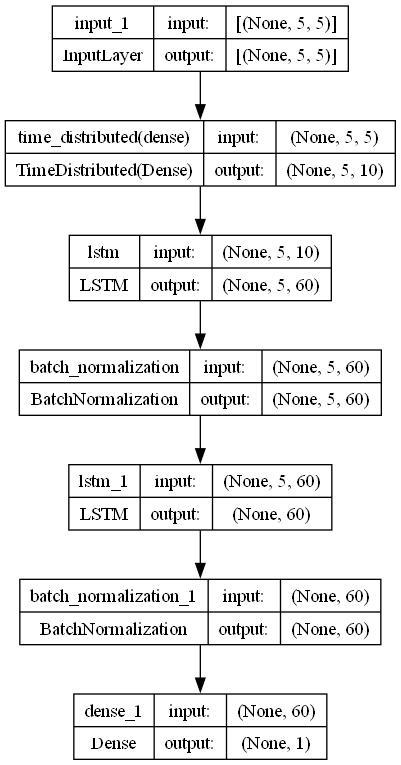

In [91]:
plot_model(model, to_file=r'.\預測結果圖\Plant2第二號發電機組\architecture.png', show_shapes=True, show_layer_names=True) 

In [92]:
# Define the model checkpoint callback
# Save the best model based on validation loss (lowest RMSE)
model_checkpoint = ModelCheckpoint(
    filepath='model/best_model.hdf5',  # Use .h5 extension for model saving
    monitor='val_loss',
    save_best_only=True,
    verbose=1  # Print out saving messages
)

# Add early stopping to stop training if the model stops improving
early_stopping = EarlyStopping(
    monitor='val_loss',  # Stop if RMSE doesn't improve
    patience=10,  # Wait 10 epochs before stopping
    restore_best_weights=True,  # Restore the best weights after stopping
    verbose=1
)

# 定義 ReduceLROnPlateau 回調函數
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # 監控指標 (驗證集 RMSE)
    factor=0.5,  # 每次學習率減少的比例 (將學習率減半)
    patience=4,  # 若監控指標未改善，等待 5 個 epoch 再減少學習率
    min_lr=1e-7,  # 最低學習率限制
    verbose=1  # 顯示學習率調整的訊息
)

csv_logger = CSVLogger('.\預測結果圖\Plant2第二號發電機組\epoch_log.csv') # 將每個訓練週期的損失和評估指標記錄到 CSV 文件中

In [93]:
Adam_optimizer = Adam(learning_rate=1e-3) # 標準Adam優化器
print(f'優化器參數: {Adam_optimizer.get_config()}')

優化器參數: {'name': 'Adam', 'learning_rate': 0.001, 'decay': 0.0, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}


In [94]:
model.compile(optimizer=Adam_optimizer, loss='mse', metrics=['mse', 'mae'])
print(model.summary())

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 5, 5)]            0         
                                                                 
 time_distributed (TimeDistr  (None, 5, 10)            60        
 ibuted)                                                         
                                                                 
 lstm (LSTM)                 (None, 5, 60)             17040     
                                                                 
 batch_normalization (BatchN  (None, 5, 60)            240       
 ormalization)                                                   
                                                                 
 lstm_1 (LSTM)               (None, 60)                29040     
                                                                 
 batch_normalization_1 (Batc  (None, 60)               240   

In [95]:
# Fit the model with better structure, additional callbacks, and dynamic batch size
H = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),  # Provide validation data for real-time evaluation
    epochs=500,  
    batch_size=128, # 也可以測試 32, 64, 128 比較效果
    callbacks=[model_checkpoint, early_stopping, reduce_lr, csv_logger],  
    verbose=1  # Show training progress
)

H

Epoch 1/500
17/21 [=======================>......] - ETA: 0s - loss: 1.2373 - mse: 0.0968 - mae: 0.2476 
Epoch 1: val_loss improved from inf to 1.06281, saving model to model\best_model.hdf5
21/21 [==============================] - 3s 26ms/step - loss: 1.2067 - mse: 0.0922 - mae: 0.2389 - val_loss: 1.0628 - val_mse: 0.1241 - val_mae: 0.3148 - lr: 0.0010
Epoch 2/500
17/21 [=======================>......] - ETA: 0s - loss: 0.8916 - mse: 0.0639 - mae: 0.1887
Epoch 2: val_loss improved from 1.06281 to 0.77282, saving model to model\best_model.hdf5
21/21 [==============================] - 0s 9ms/step - loss: 0.8709 - mse: 0.0641 - mae: 0.1894 - val_loss: 0.7728 - val_mse: 0.1049 - val_mae: 0.2895 - lr: 0.0010
Epoch 3/500
17/21 [=======================>......] - ETA: 0s - loss: 0.6460 - mse: 0.0572 - mae: 0.1848
Epoch 3: val_loss improved from 0.77282 to 0.56450, saving model to model\best_model.hdf5
21/21 [==============================] - 0s 9ms/step - loss: 0.6308 - mse: 0.0566 - mae: 0.1

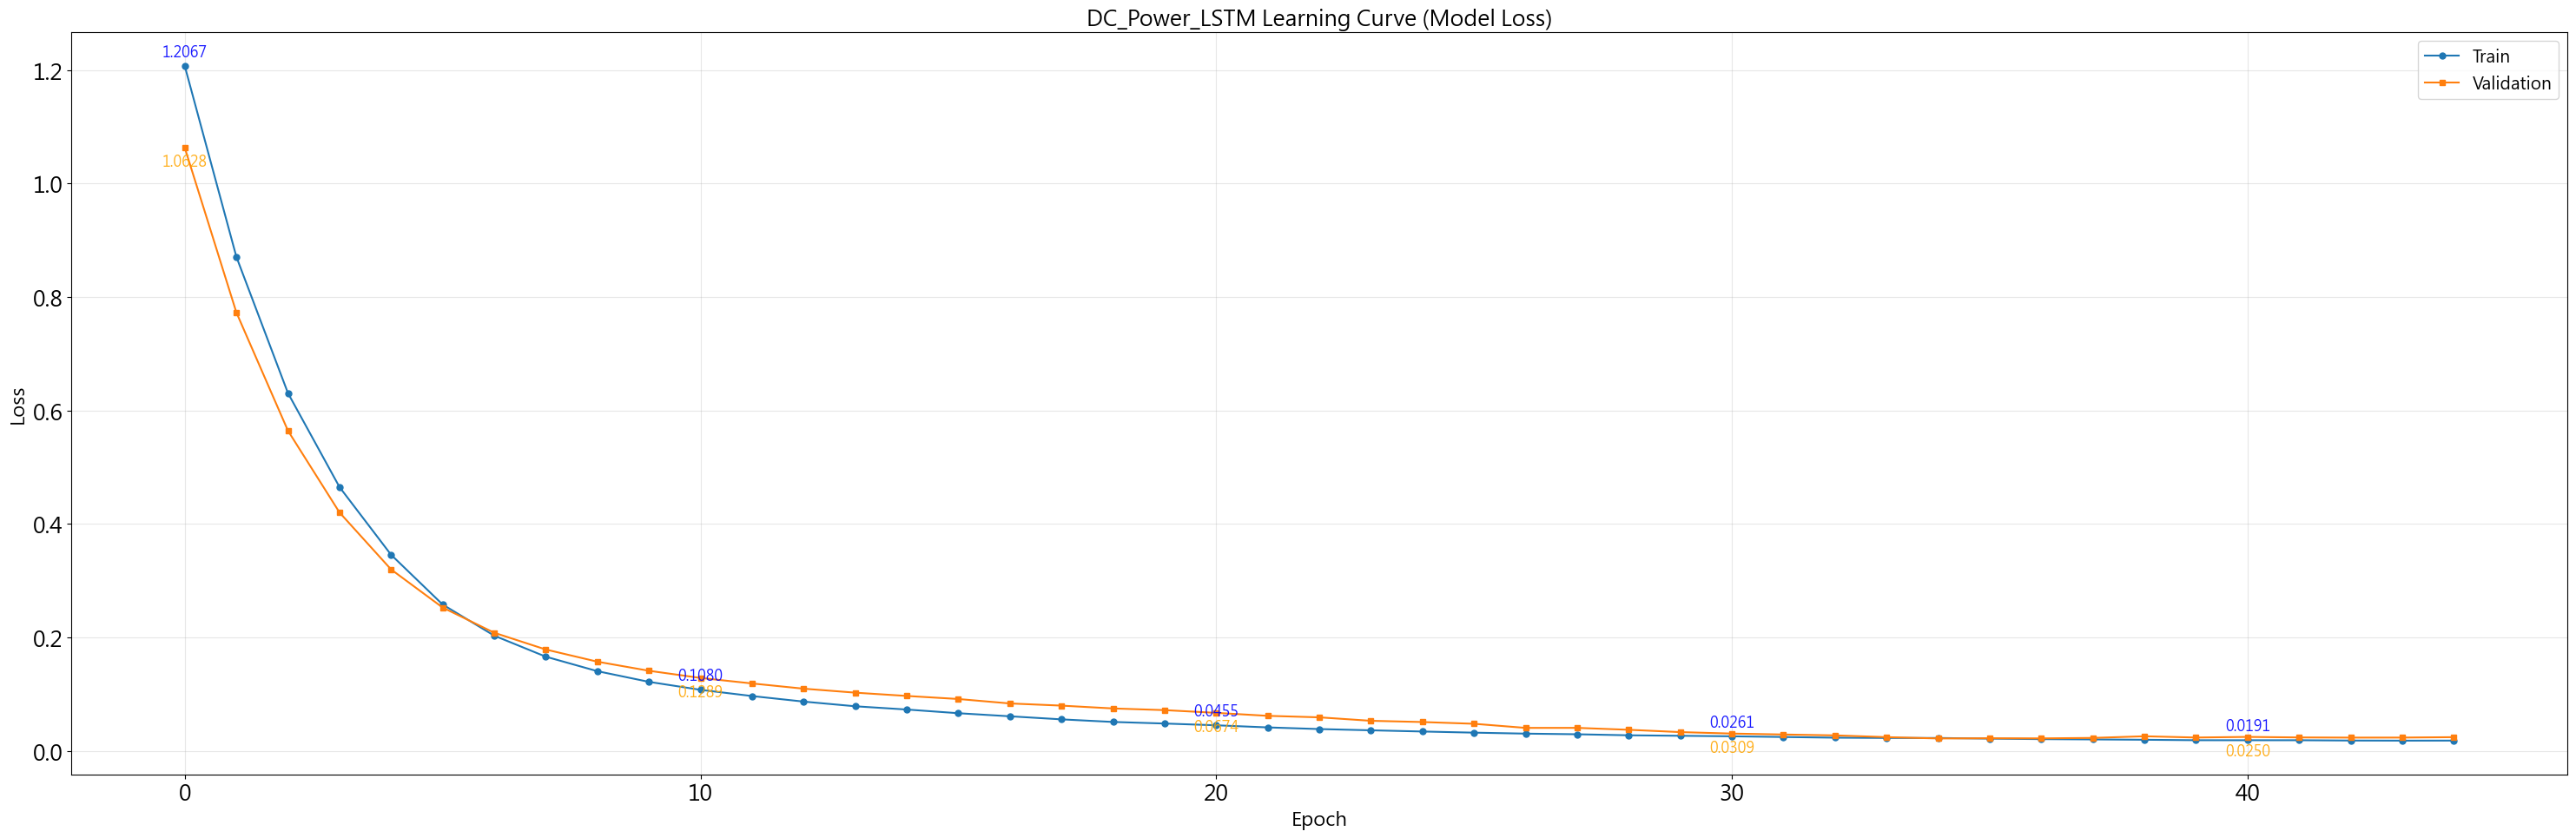

Plot saved to .\預測結果圖\Plant2第二號發電機組\DC_Power_LSTM Learning Curve.png


In [96]:
save_lr_curve(H, f_name="DC_Power_LSTM")

In [97]:
# from tensorflow.keras.models import load_model

# # Load the best saved model
# model1 = load_model('model1/best_model.keras')
# model1.summary()

<h3> 評估模型 </h3>

<h4> TRAIN DATASET </h4>
對訓練數據進行預測

In [98]:
# Make predictions on the training data
train_predictions = model.predict(X_train).flatten() # 轉成一維陣列 → 方便後續比較與畫圖

# 比較預測值與實際值
train_results = pd.DataFrame({
    'Train Predictions': train_predictions, # 模型預測值
    'Actual Values': y_train.flatten() # 實際值
})

train_results

82/82 [==============================] - 1s 3ms/step


,Train Predictions,Actual Values
0,0.048025,0.0
1,0.049842,0.0
2,0.052062,0.0
3,0.054477,0.0
4,0.057026,0.0
...,...,...
2595,0.053657,0.0
2596,0.056016,0.0
2597,0.058689,0.0
2598,0.061658,0.0


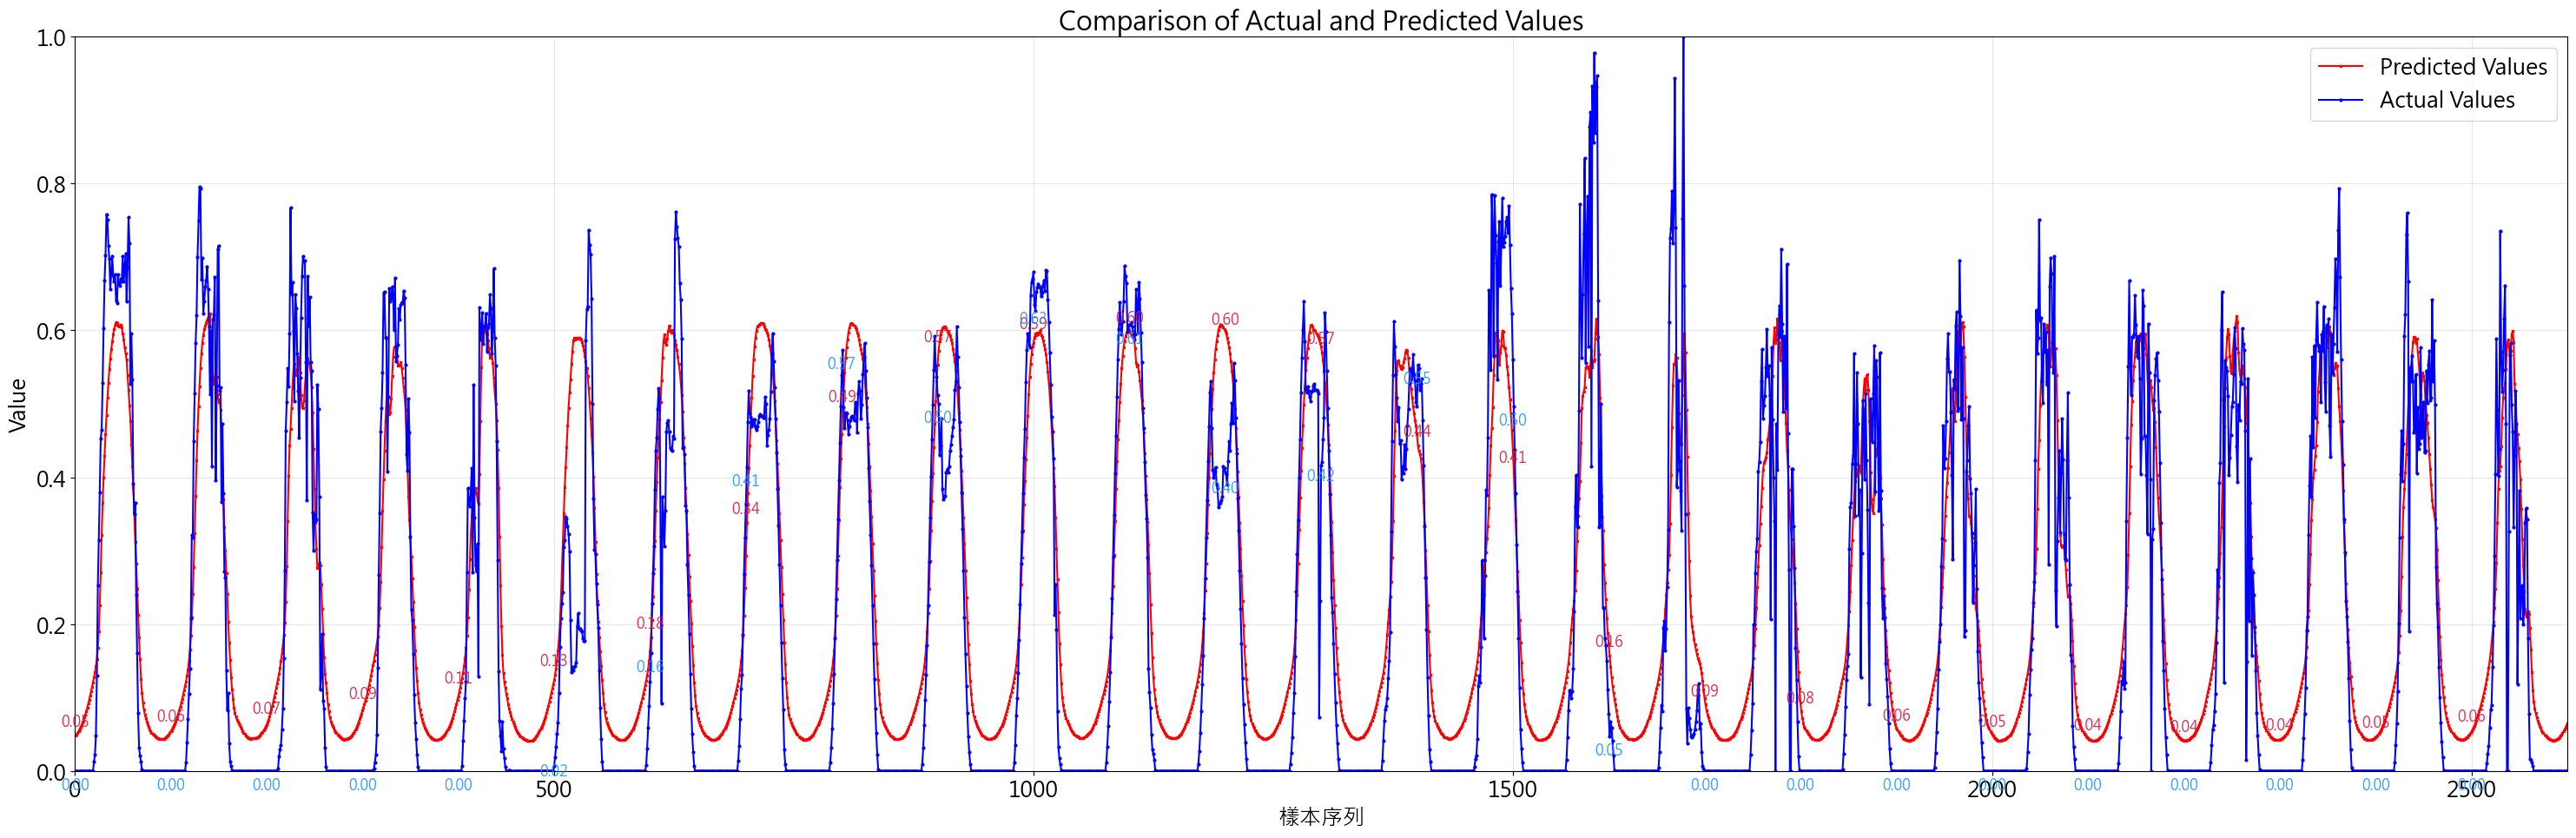

Plot saved to .\預測結果圖\Plant2第二號發電機組\TRAIN prediction.png


In [99]:
save_prediction_plot(train_results['Actual Values'], train_results['Train Predictions'], mode='TRAIN') # 繪製y_test與y_test_pred的對比圖，展示預測值與實際值的偏差 (折線圖)

兩條線大致重合，模型表現良好

<h4> VALIDATION DATA </h4>
對驗證集進行預測

In [100]:
val_predictions = model.predict(X_val).flatten()

# Create a DataFrame to compare predictions and actual values
val_results = pd.DataFrame({
    'Val Predictions': val_predictions,
    'Actual Values': y_val.flatten()  
})

val_results

10/10 [==============================] - 0s 4ms/step


,Val Predictions,Actual Values
0,0.068224,0.000000
1,0.071896,0.000000
2,0.076028,0.000000
3,0.080545,0.000000
4,0.085422,0.000000
...,...,...
295,0.100943,0.000000
296,0.107070,0.000000
297,0.113474,0.000000
298,0.120031,0.000000


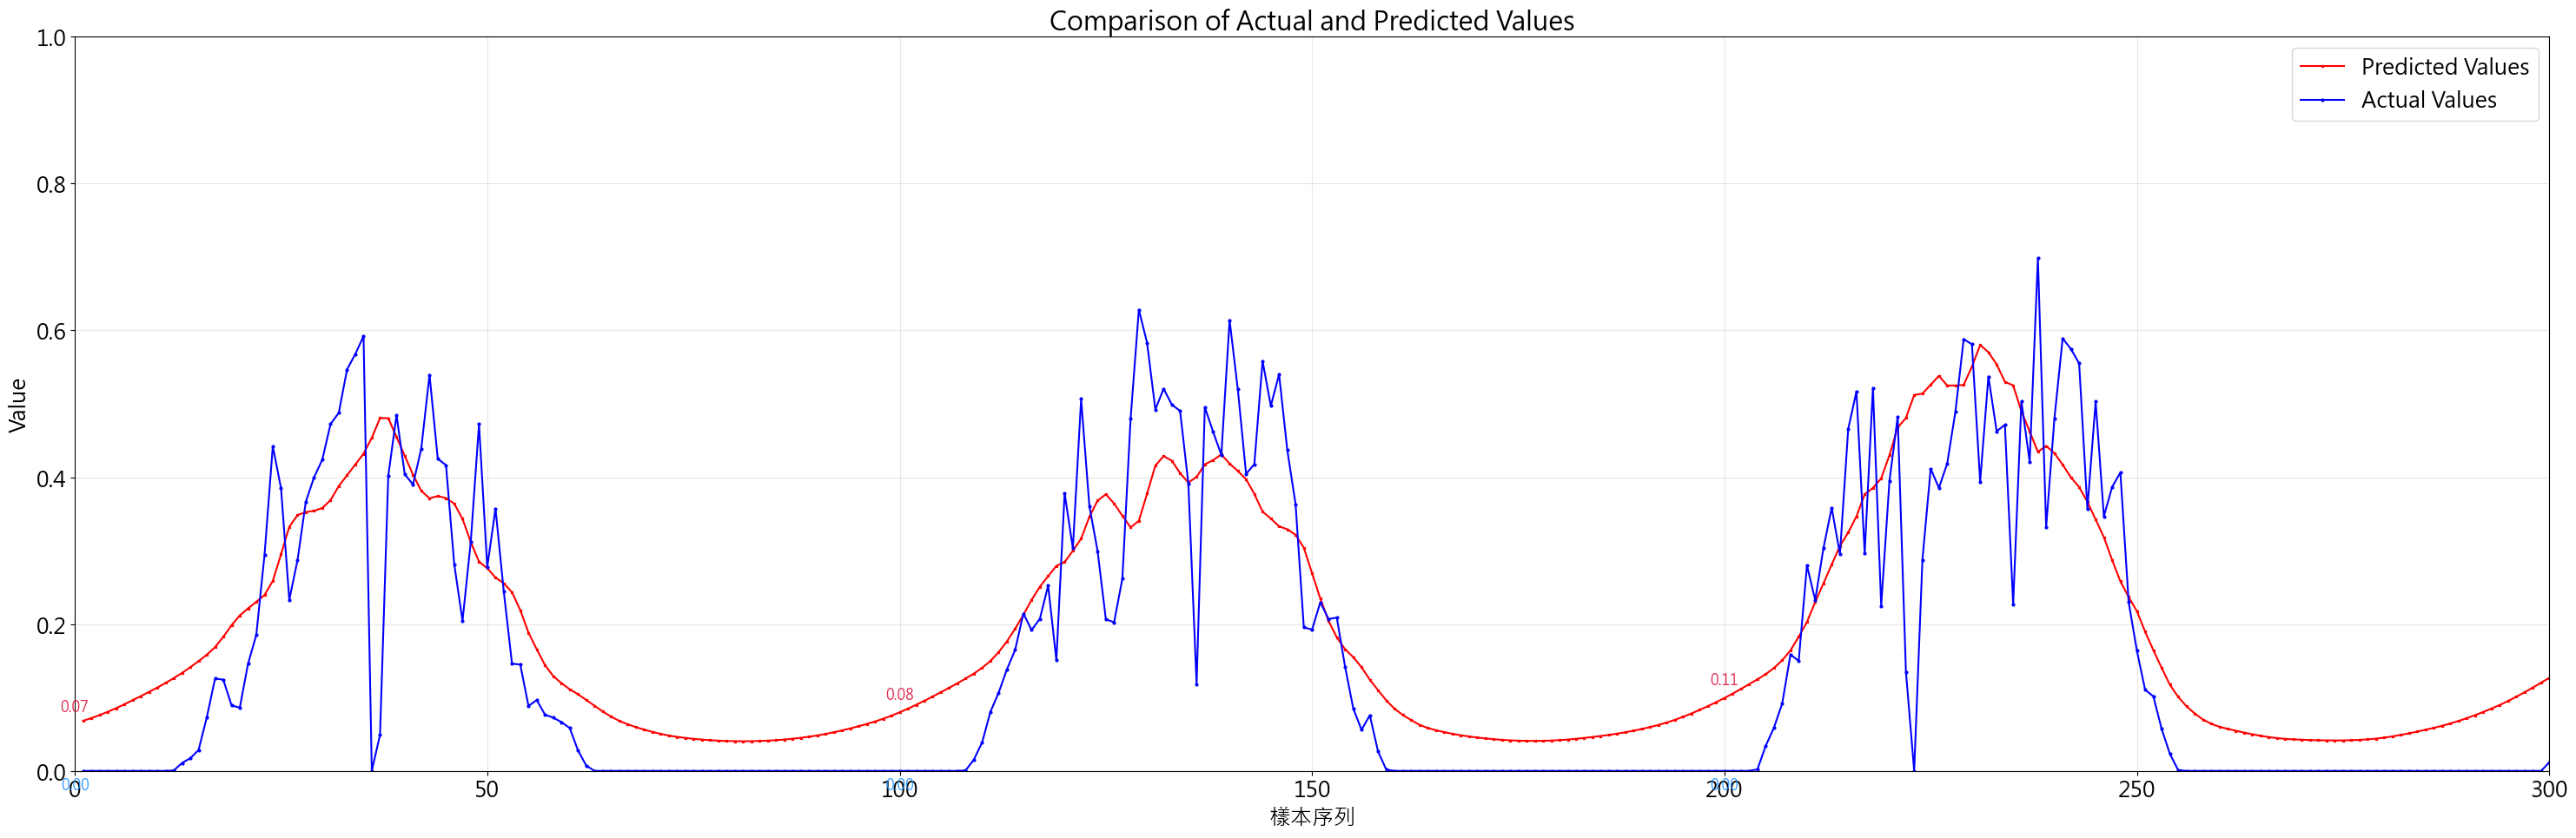

Plot saved to .\預測結果圖\Plant2第二號發電機組\VALIDATION prediction.png


In [101]:
save_prediction_plot(val_results['Actual Values'], val_results['Val Predictions'], mode='VALIDATION') # 繪製y_test與y_test_pred的對比圖，展示預測值與實際值的偏差 (折線圖)

兩條線高度重合，模型表現良好

<h4> testing data </h4>
對測試集進行預測

In [102]:
# Make predictions on the test data
test_predictions = model.predict(X_test).flatten()

# Create a DataFrame to compare predictions and actual values
test_results = pd.DataFrame({
    'Test Predictions': test_predictions,
    'Actual Values': y_test.flatten()  # Ensure y_test is flattened for consistency
})

# Display the first few rows of the DataFrame
test_results

12/12 [==============================] - 0s 5ms/step


,Test Predictions,Actual Values
0,0.134172,0.038770
1,0.143121,0.079569
2,0.154806,0.133319
3,0.170837,0.191450
4,0.193225,0.243858
...,...,...
354,0.042214,0.000000
355,0.041787,0.000000
356,0.041543,0.000000
357,0.041495,0.000000


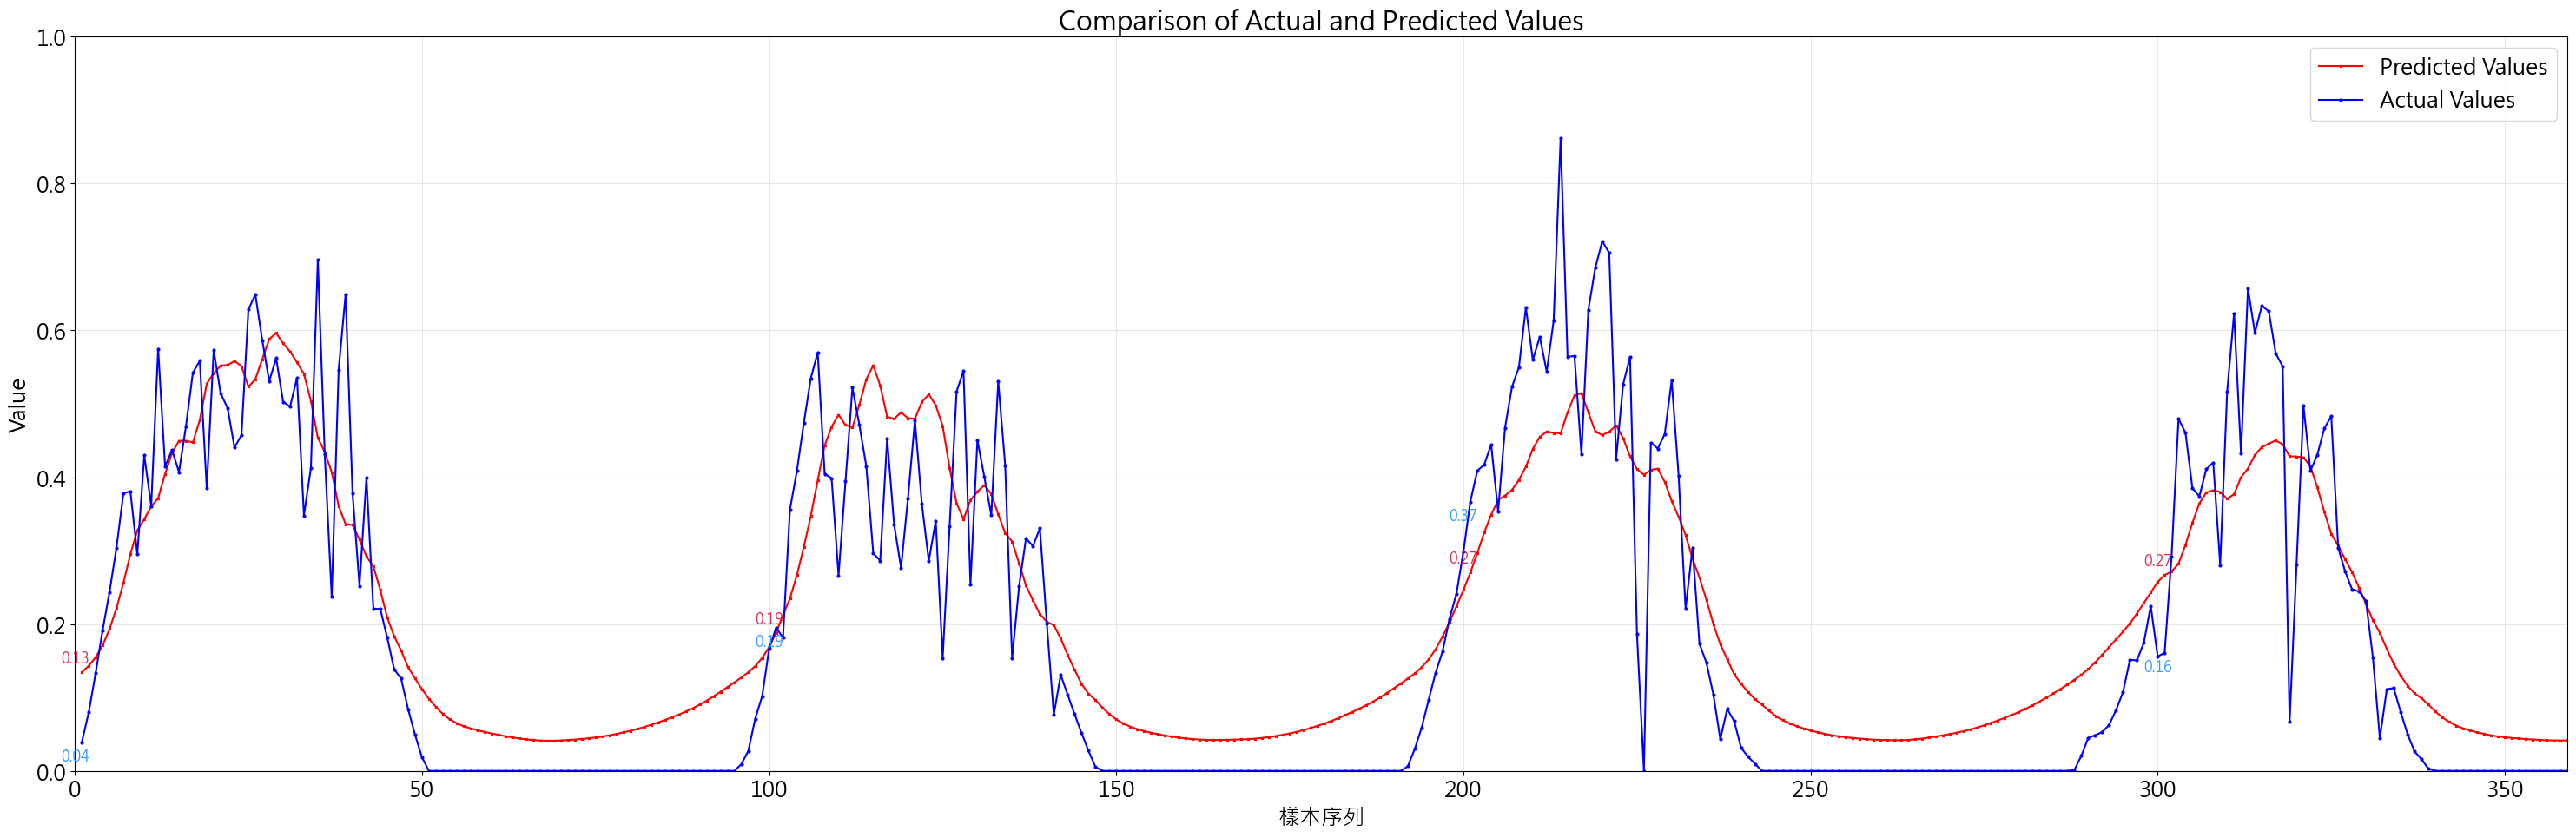

Plot saved to .\預測結果圖\Plant2第二號發電機組\TESTING prediction.png


In [103]:
save_prediction_plot(test_results['Actual Values'], test_results['Test Predictions'], mode='TESTING') # 繪製y_test與y_test_pred的對比圖，展示預測值與實際值的偏差 (折線圖)

<h4> 評估模型在測試數據集上的表現 </h4>

In [104]:
metric_score(y_test.flatten(), test_predictions, model=model)

Mean Squared Error (MSE): 0.0103
Root Mean Squared Error (RMSE): 0.1015
Mean Absolute Error (MAE): 0.0817
R² Score: 0.7876


(<tf.Tensor: shape=(), dtype=float32, numpy=0.010307015>,
 0.10152347,
 <tf.Tensor: shape=(), dtype=float32, numpy=0.081697494>,
 0.7875698771011056)

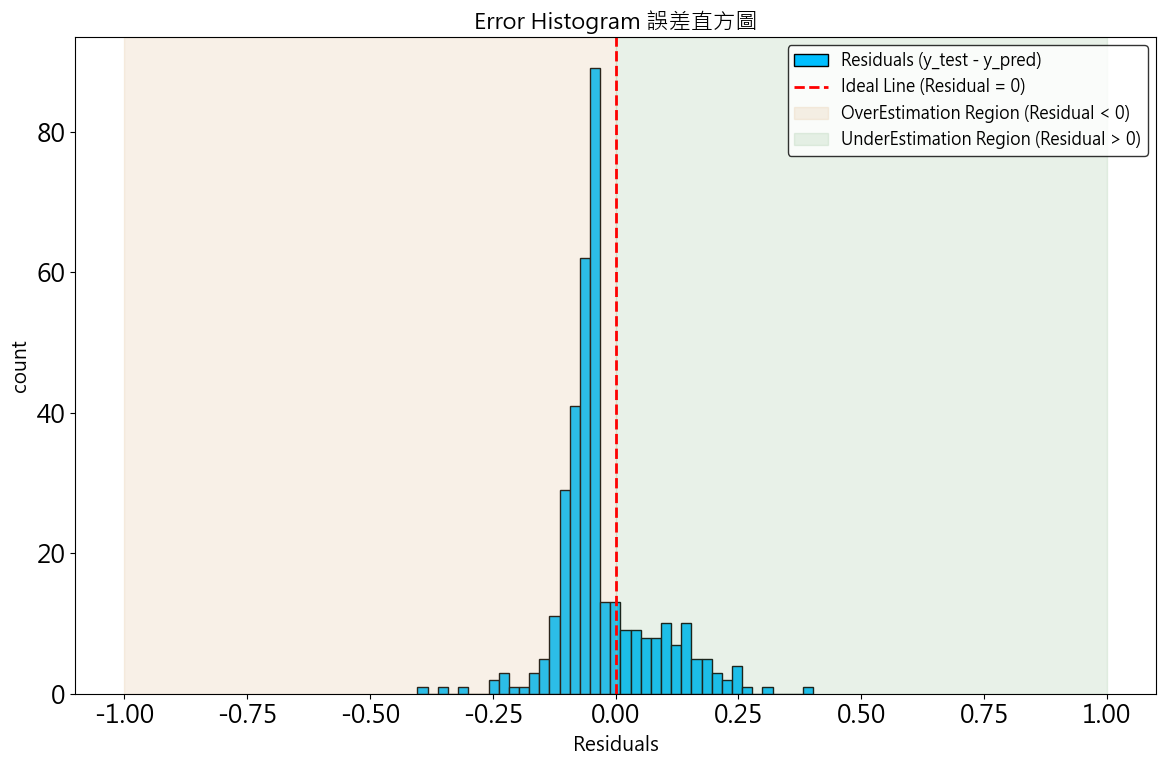

Plot saved to .\預測結果圖\Plant2第二號發電機組\Error Histogram.png


In [105]:
ErrorHistogram(y_test.flatten(), test_predictions)

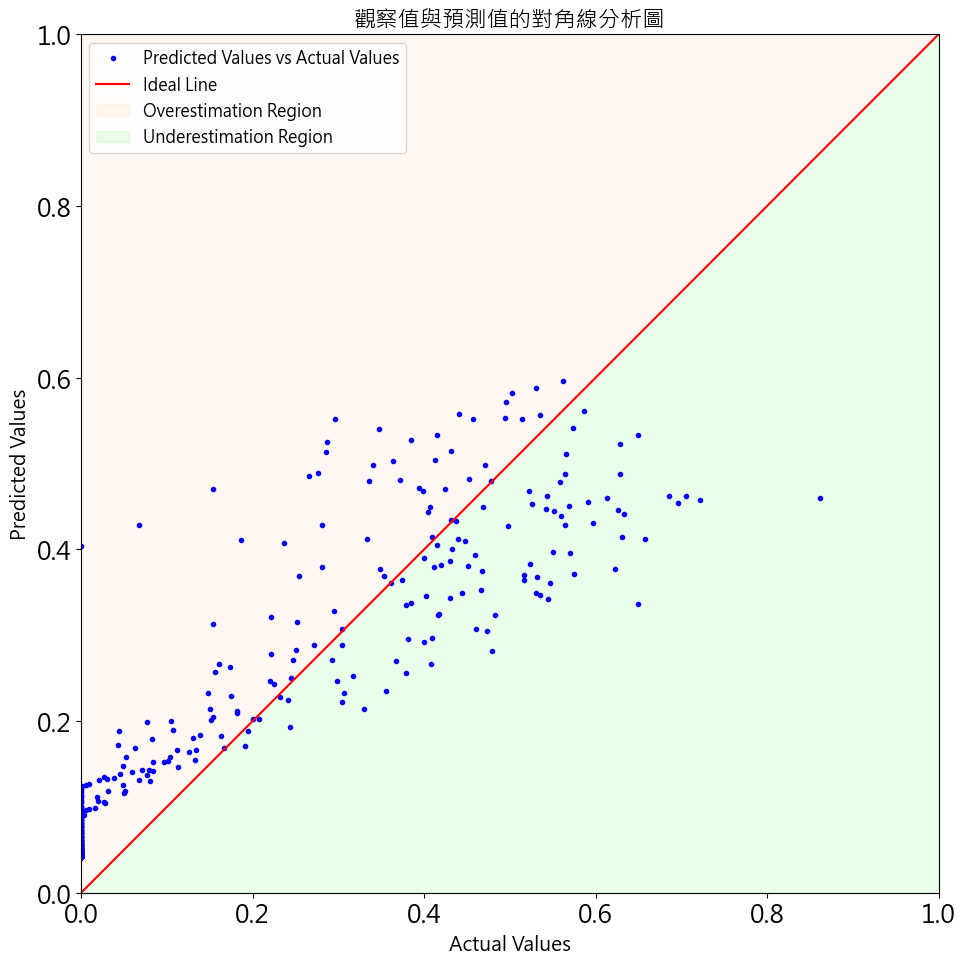

Plot saved to .\預測結果圖\Plant2第二號發電機組\yy_plot.png


In [106]:
save_yy_plot(y_test.flatten(), test_predictions)